# Load Packages and experimental values

In [1]:

import jax, os
print("jax", jax.__version__)
print("jaxlib", jax.lib.__version__)
print("JAX_PLATFORMS =", os.environ.get("JAX_PLATFORMS"))
print("LD_LIBRARY_PATH =", os.environ.get("LD_LIBRARY_PATH"))
print(jax.devices())


jax 0.6.2
jaxlib 0.6.2
JAX_PLATFORMS = None
LD_LIBRARY_PATH = None
[CudaDevice(id=0)]


In [2]:
import jax
import jax.numpy as jnp
import jax.scipy as jsp
from functools import partial



import optax
import flax.linen as nn
from flax.training.train_state import TrainState
 
import matplotlib.pyplot as plt

import sys
import json
from pathlib import Path
from toolbox import *

In [3]:
seed = 1234
key = jax.random.key(seed)

### Load json

In [4]:
def _strip_comment_keys(obj):
    """Recursively drop any keys that start with '//'."""
    if isinstance(obj, dict):
        return {k: _strip_comment_keys(v) for k, v in obj.items()
                if not (isinstance(k, str) and k.startswith("//"))}
    if isinstance(obj, list):
        return [_strip_comment_keys(x) for x in obj]
    return obj

def load_config_dict(config_directory: Path, filename: str = "configuration.json") -> dict:
    path = (config_directory / filename).resolve()
    with path.open("r", encoding="utf-8") as f:
        data = json.load(f)
    return _strip_comment_keys(data)

config_directory = Path("")
cfg = load_config_dict(config_directory, "configuration.json")

# Hamiltonian parameters (MHz units)
chi = -2 * jnp.pi * cfg["chi_kHz"] * 1e-3
qubit_anham = 2 * jnp.pi * cfg["anharmonicity_MHz"]
K_cg = 2*jnp.pi*cfg["self_Kerr_kHz"]*1e-3  # cavity self-Kerr MHz
K_ce = 2*jnp.pi*cfg["self_Kerr_if_qubit_in_e_kHz"]*1e-3  # cavity self-Kerr MHz
readout_lenght_ns = cfg["readout_len"]


print("chi (MHz)", chi / (2 * jnp.pi))
print("qubit anham (MHz)", qubit_anham / (2 * jnp.pi))
print("cavity self-Kerr ground (MHz)", K_cg / (2 * jnp.pi))
print("cavity self-Kerr excited (MHz)", K_ce / (2 * jnp.pi))


# Relaxation times (not used in this unitary optimizer, but keep)
t1_qub = cfg["qubit_T1_us"]
t2_qub = cfg["qubit_T2_us"]
t1_cav = cfg["storage_T1_us"]

chi (MHz) -0.6597474879999999
qubit anham (MHz) -164.25838108
cavity self-Kerr ground (MHz) -0.0007143000000000001
cavity self-Kerr excited (MHz) -0.00035699999999999995


# Static constants (should not be modified during training)

In [5]:

num_bspln = 20    # Desired number of basis pulses
delta_ns = 64 # Grid interval, must be a multiple of 4ns. (proportional to control pulse duration devided by bspline number)


inp_shape = (1,) #should not be modified at all (size of a measurement)
rec_features = num_bspln * 4#should not be modified at all (size of output)
dense_features = [int(rec_features * 2),int(rec_features * 2)] #can be modified to modify the neural network size (feedback time should be modified accordingly)
print("rec_features:", rec_features)
print("dense_features:" , dense_features)

big_nn = (len(dense_features)==3) #assumes either 3 or 2 hidden layers


rec_features: 80
dense_features: [160, 160]


# Initialize the RNN

In [6]:
def init_carry(key, rec_features, inp_shape):
    gru_cell = nn.GRUCell(features=rec_features)
    return gru_cell.initialize_carry(key, inp_shape)

def create_flax_state(key,
                      rec_features, dense_features,
                      inp_shape, learning_rate,
                      *, print_summary):
    
    class Model(nn.Module):
    
        @nn.compact
        def __call__(self, carry, x):
            
            gru_cell = nn.GRUCell(features=rec_features)
            carry, x = gru_cell(carry, x)
            
            for ndf in dense_features:
                x = nn.Dense(ndf)(x)
                x = jax.nn.relu(x)
                
            out_layer = nn.Dense(4 * num_bspln)
            x = out_layer(x)
            x = x.reshape(4, num_bspln)
            
            return carry, x

    model = Model()

    fake_key = jax.random.key(0)
    fake_carry = init_carry(fake_key, rec_features, inp_shape)
    fake_inp = jnp.ones(inp_shape)
    params = model.init(key, fake_carry, fake_inp)["params"]

    # optimizer = optax.adam(learning_rate=learning_rate)
    optimizer = optax.chain( #avoid unlikely trajectory to create catastrophic update
    optax.clip_by_global_norm(1.0),
    optax.adam(learning_rate=learning_rate),
    )

    flax_state = TrainState.create(apply_fn=model.apply, params=params, tx=optimizer)

    if print_summary:
        print(model.tabulate(fake_key, fake_carry, fake_inp))

    return flax_state

def apply_nn(flax_state, params, carry, inp):
    return flax_state.apply_fn({'params': params}, carry, inp)

key, subkey = jax.random.split(key)
flax_state = create_flax_state(
    subkey, rec_features, dense_features, inp_shape, 1e-4,
    print_summary=True
)


                                 Model Summary                                  
┏━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ path         ┃ module  ┃ inputs        ┃ outputs         ┃ params            ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│              │ Model   │ - float32[80] │ - float32[80]   │                   │
│              │         │ - float32[1]  │ - float32[4,20] │                   │
├──────────────┼─────────┼───────────────┼─────────────────┼───────────────────┤
│ GRUCell_0    │ GRUCell │ - float32[80] │ - float32[80]   │                   │
│              │         │ - float32[1]  │ - float32[80]   │                   │
├──────────────┼─────────┼───────────────┼─────────────────┼───────────────────┤
│ GRUCell_0/ir │ Dense   │ float32[1]    │ float32[80]     │ bias: float32[80] │
│              │         │               │                 │ kernel:           │
│              │         │ 

## Load pretrained network

In [7]:
load_name = "fg_trained/fock2"
load_timestamp = None
# load_timestamp = "20260626_1345"  # or specify one manually

load_trained = True

if load_trained:

    from pathlib import Path
    import orbax.checkpoint as ocp

    load_root = Path(load_name).resolve()
    resume_step = 1

    if load_timestamp is None:
        timestamp_folders = sorted([
            p for p in load_root.iterdir()
            if (
                p.is_dir()
                and len(p.name) == 13
                and p.name[8] == "_"
                and p.name[:8].isdigit()
                and p.name[9:].isdigit()
                and (p / "params_only" / str(resume_step)).exists()
            )
        ])

        resume_save_name = timestamp_folders[-1]

    else:
        resume_save_name = load_root / load_timestamp

    def load_flax_params_from_orbax(fld, state_template, *, step=1):
        ckpt_path = Path(fld).resolve() / "params_only" / str(step)
        if not ckpt_path.exists():
            raise FileNotFoundError(f"Params checkpoint directory not found: {ckpt_path}")

        ckptr = ocp.Checkpointer(ocp.StandardCheckpointHandler())
        restored_params = ckptr.restore(
            ckpt_path,
            args=ocp.args.StandardRestore(state_template.params),
        )
        return state_template.replace(params=restored_params)

    flax_state = load_flax_params_from_orbax(
        resume_save_name,
        flax_state,
        step=resume_step,
    )

    print(f"Loaded NN params from: {Path(resume_save_name).resolve() / 'params_only' / str(resume_step)}")
    print("Loaded timestamp folder:", Path(resume_save_name).name)
    print("Current TrainState step:", int(flax_state.step))

Loaded NN params from: /home/user/python_experiments/train_feedback_grape/fg_trained/fock2/20260703_1015/params_only/1
Loaded timestamp folder: 20260703_1015
Current TrainState step: 0


# Physical description of the systems evolution

## Idle evolution: storage Kerr + storage decay

During the feedback-GRAPE trajectory, the system alternates between three operations:

1. qubit measurement,
2. idle evolution,
3. driven control pulse.

After the measurement, `measure_sz(...)` projects the qubit and resets it to the ground state $|g\rangle$. Therefore, during the following idle time, we assume that the qubit is in $|g\rangle$.

In the rotating frame used here, the dispersive interaction does not produce an additional cavity rotation while the qubit is in $|g\rangle$. However, the storage cavity still evolves because of two effects:

- storage self-Kerr,
- finite storage lifetime $T_{1,\mathrm{cav}}$.

We therefore model the idle cavity dynamics with the Lindblad master equation

$$
\frac{d\rho}{dt}
=
-i[H_{\mathrm{Kerr}},\rho]
+
\kappa_{\mathrm{cav}}\mathcal{D}[a]\rho,
$$

where

$$
H_{\mathrm{Kerr}}
=
\frac{K_c}{2}a^\dagger a^\dagger a a
=
\frac{K_c}{2}\hat n(\hat n-1),
$$

and

$$
\kappa_{\mathrm{cav}} = \frac{1}{T_{1,\mathrm{cav}}}.
$$

The dissipator is

$$
\mathcal{D}[a]\rho
=
a\rho a^\dagger
-
\frac{1}{2}a^\dagger a\rho
-
\frac{1}{2}\rho a^\dagger a.
$$

Physically, the Kerr term gives a photon-number-dependent phase. A Fock state $|n\rangle$ acquires an energy proportional to

$$
\frac{K_c}{2}n(n-1).
$$

Therefore, a superposition of Fock states does not only rotate rigidly in phase space. Its different photon-number components accumulate different phases, which slowly deforms the cavity state. This matters especially for cat states and other nonclassical states.

The decay term models photon loss. Since $T_{1,\mathrm{cav}}$ is long, this effect is weak, but it should still be included because idle evolution is repeated many times during the trajectory.

The full idle Liouvillian is

$$
\mathcal{L}_{\mathrm{idle}}
=
-i[H_{\mathrm{Kerr}},\cdot]
+
\kappa_{\mathrm{cav}}\mathcal{D}[a].
$$

The finite-time idle channel is then computed as

$$
\rho(t_{\mathrm{idle}})
=
\exp\left(\mathcal{L}_{\mathrm{idle}}t_{\mathrm{idle}}\right)
\rho(0).
$$

Thus Kerr and decay are simulated simultaneously, rather than as two separate approximate steps.

### Liouville-space representation

In the code, the density matrix is flattened with

```python
rho.reshape(-1, 1)
```

This turns the density matrix into a vector. The Lindblad dissipator is then represented as a large matrix acting on this vector.

For row-major vectorization, the useful identity is

$$
\mathrm{vec}_R(A\rho B)
=
(A\otimes B^T)\mathrm{vec}_R(\rho).
$$

Therefore,

$$
\mathrm{vec}_R(c\rho c^\dagger)
=
(c\otimes c^*)\mathrm{vec}_R(\rho),
$$

because $(c^\dagger)^T = c^*$.

Similarly, if

$$
M = c^\dagger c,
$$

then

$$
\mathrm{vec}_R(M\rho)
=
(M\otimes I)\mathrm{vec}_R(\rho),
$$

and

$$
\mathrm{vec}_R(\rho M)
=
(I\otimes M^T)\mathrm{vec}_R(\rho).
$$

This is why the code builds

$$
L
=
c\otimes c^*
-
\frac{1}{2}c^\dagger c\otimes I
-
\frac{1}{2}I\otimes (c^\dagger c)^T.
$$

Acting with this matrix on the vectorized density matrix gives

$$
L\mathrm{vec}_R(\rho)
=
\mathrm{vec}_R\left(
\mathcal{D}[c]\rho
\right).
$$

So `liouv_relax_channel(c)` does not directly evolve the state. It builds the Liouville-space matrix corresponding to the dissipator $\mathcal{D}[c]$.

### Efficiency approximation

The idle channel is built only on the cavity Hilbert space. This is allowed because `idle(rho)` is called immediately after `measure_sz(...)`, which resets the qubit to $|g\rangle$.

Therefore, instead of evolving the full qubit-cavity density matrix during idle, the code extracts

$$
\rho_{\mathrm{cav}}
=
\langle g|\rho|g\rangle,
$$

applies the cavity-only idle channel, and reconstructs

$$
\rho_{\mathrm{out}}
=
|g\rangle\langle g|
\otimes
\rho_{\mathrm{cav}}.
$$

This is much cheaper than building the full qubit-cavity Liouvillian. For a cavity cutoff $N_{\mathrm{cav}}$, the cavity-only Liouville space has dimension $N_{\mathrm{cav}}^2$, whereas the full qubit-cavity Liouville space has dimension $(2N_{\mathrm{cav}})^2 = 4N_{\mathrm{cav}}^2$.

The functions in the code have the following roles:

- `liouv_relax_channel(c)` builds the dissipative part $\mathcal{D}[c]$ in Liouville space.
- `liouv_hamiltonian(H)` builds the coherent part $-i[H,\rho]$ in Liouville space.
- `make_cavity_idle_matrix(...)` builds $\mathcal{L}_{\mathrm{idle}}$ and exponentiates it.
- `make_idle(...)` applies this cavity-only idle channel and restores the qubit to $|g\rangle$.

This approximation is valid only because the idle evolution is used immediately after qubit measurement and reset. If the same idle function were used while the qubit could still be in $|e\rangle$ or in a superposition, then the full qubit-cavity Hamiltonian would need to be included again.

Finally, all units must be consistent. For example, if times are in microseconds, then $K_c$ should be in rad/µs and $T_{1,\mathrm{cav}}$ should be in µs.

In [8]:
def liouv_relax_channel(c):
    """
    Row-major vectorization convention, consistent with rho.reshape(-1, 1).

    Implements:
        D[c] rho = c rho c^dag - 1/2 {c^dag c, rho}
    """
    d = c.shape[0]
    I = identity(d)

    cdag_c = hconj(c) @ c

    L = tensor(c, c.conj())
    L -= 0.5 * tensor(cdag_c, I)
    L -= 0.5 * tensor(I, cdag_c.T)

    return L


def liouv_hamiltonian(H):
    """
    Row-major vectorization convention.

    Implements:
        -i [H, rho]
    """
    d = H.shape[0]
    I = identity(d)

    return -1j * (tensor(H, I) - tensor(I, H.T))


def make_cavity_idle_matrix(N_cav, t1_cav, t_idle):
    """
    Exact idle Lindblad channel for the storage cavity.

    Includes simultaneously:
        - self-Kerr
        - cavity T1

    This is only a cavity channel, because in this notebook idle is called
    immediately after measure_sz(...), which resets the qubit to |g>.
    """
    a = destroy(N_cav)
    adag = hconj(a)

    H_kerr_cav = 0.5 * K_cg * adag @ adag @ a @ a

    c_loss = a / jnp.sqrt(t1_cav)

    L_idle = liouv_hamiltonian(H_kerr_cav)
    L_idle += liouv_relax_channel(c_loss)

    return jsp.linalg.expm(L_idle * t_idle)


def make_idle_cav(N_cav, t1_qub, t2_qub, t1_cav, t_idle):
    """
    Same public signature as before.

    t1_qub and t2_qub are intentionally unused, because after measure_sz(...)
    the qubit has already been projected and reset to |g>.
    """
    idle_cav_matrix = make_cavity_idle_matrix(N_cav, t1_cav, t_idle)

    g = basis(2)
    rho_g = g @ hconj(g)

    def idle_cav(rho):
        # rho has block structure:
        # [ rho_gg   rho_ge ]
        # [ rho_eg   rho_ee ]
        #
        # After measure_sz(...), it should be |g><g| tensor rho_cav.
        rho_cav = rho[:N_cav, :N_cav]

        rho_cav_liouv = rho_cav.reshape(-1, 1)
        rho_cav_liouv = idle_cav_matrix @ rho_cav_liouv
        rho_cav = rho_cav_liouv.reshape((N_cav, N_cav))

        rho_out = tensor(rho_g, rho_cav)
        rho_out /= jnp.trace(rho_out)

        return rho_out

    return idle_cav


print("sigma.m =", sigma.m)

sigma.m = [[0.+0.j 0.+0.j]
 [1.+0.j 0.+0.j]]


## Drive with decay

In [9]:
mu_qub = 20.0 #make the coeff big enough so that the amps remain betwee -2 and 2 (don't modify the coef unless you modify it in the qua programm too)
mu_cav = 20.0


def build_drive_htree(N_cav, chi, e_qub, e_cav):
    a = tensor(identity(2), destroy(N_cav))
    adag = hconj(a)
    n_phot = adag @ a
    sigz = tensor(sigma.z, identity(N_cav))
    sigp = tensor(sigma.p, identity(N_cav))
    one = tensor(identity(2), identity(N_cav))

    H_disp = (chi / 2) * n_phot @ (one - sigz)
    # H_kerr = 0.5 * K_c * adag @ adag @ a @ a
    # state dependent cavity kerr
    proj_g = 0.5 * (one + sigz)
    proj_e = 0.5 * (one - sigz)
    kerr_op = adag @ adag @ a @ a
    H_kerr = 0.5 * (K_cg * proj_g + K_ce * proj_e) @ kerr_op


    # Combined drift Hamiltonian
    H_drift = H_disp + H_kerr
    
    ht = [
        [H_drift, 1, 1, 0],
        [mu_qub * sigp, e_qub, 1, 1],                
        [mu_cav * adag, 1j *jnp.conj(e_cav), 1, 1] 
    ]
    return ht

def get_uevol_matrix(N_cav, chi, e_qub, e_cav, dt):
    htree = build_drive_htree(N_cav, chi, e_qub, e_cav)
    hmat = hmat_from_htree(htree)
    return evol_hdt_exp(hmat, dt)

def liouv_relax_channel_qubit_cav(c):
    l = tensor(c, c.conj())
    l -= 1 / 2 * tensor(hconj(c) @ c, identity(len(c)))
    l -= 1 / 2 * tensor(identity(len(c)), (hconj(c) @ c).T)
    return l

def eval_idling_matrix(cs, t):
    l = sum(liouv_relax_channel_qubit_cav(c) for c in cs)
    return jsp.linalg.expm(l * t)

def build_c_ops(N_cav, t1_qub, t2_qub, t1_cav):
    get_t_phi_qub = lambda t1, t2: 1 / ((1 / t2) - (1 / t1) / 2)
    t_phi_qub = get_t_phi_qub(t1_qub, t2_qub)

    sigm = tensor(sigma.m, identity(N_cav))
    sigz = tensor(sigma.z, identity(N_cav))
    a = tensor(identity(2), destroy(N_cav))
    
    c_ops = [
        1 / jnp.sqrt(t1_qub) * sigm,
        1 / jnp.sqrt(t_phi_qub) * sigz / jnp.sqrt(2),
        1 / jnp.sqrt(t1_cav) * a
    ]
    return c_ops

def make_idle_dt(N_cav, t1_qub, t2_qub, t1_cav, t):
    cs = build_c_ops(N_cav, t1_qub, t2_qub, t1_cav)
    idling_matrix = eval_idling_matrix(cs, t)

    def idle_dt(rho):
        rho_liouv = rho.reshape(-1, 1)
        rho_liouv = idling_matrix @ rho_liouv
        return rho_liouv.reshape(rho.shape)

    return idle_dt


def make_drive_with_relax(N_cav, chi, t1_qub, t2_qub, t1_cav, dt_idle):
    
    idle_after_drive_dt = make_idle_dt(N_cav, t1_qub, t2_qub, t1_cav, dt_idle)
    
    def drive_with_relax(rho_init, es_qub, es_cav, dts):
        
        def f(rho, x):
            e_qub, e_cav, dt = x
            uevol = get_uevol_matrix(N_cav, chi, e_qub, e_cav, dt)[0]
            rho = uevol @ rho @ hconj(uevol)
            rho = idle_after_drive_dt(rho)
            return rho, None
    
        rho_fin, _ = jax.lax.scan(f, rho_init, [es_qub, es_cav, dts])
        
        return rho_fin
    
    return drive_with_relax


# def make_drive(N_cav, chi):
    
#     def drive(rho_init, es_qub, es_cav, dts):
        
#         def f(rho, x):
#             e_qub, e_cav, dt = x
#             uevol = get_uevol_matrix(N_cav, chi, e_qub, e_cav, dt)[0]
#             return uevol @ rho @ hconj(uevol), None
    
#         rho_fin, _ = jax.lax.scan(f, rho_init, [es_qub, es_cav, dts])
#         return rho_fin
    
#     return drive

def ctrl_from_coeffs(ctrl_coeffs, bsplns):
    ctrls_real = ctrl_coeffs @ bsplns
    e_qub = ctrls_real[0, ...] + 1j * ctrls_real[1, ...]
    e_cav = ctrls_real[2, ...] + 1j * ctrls_real[3, ...]
    return e_qub, e_cav

## Measurement with qubit reset and readout backaction

### Effective qubit readout model

At each feedback step, the input state is the full qubit+cavity density matrix $\rho$.  
The qubit readout is modeled as a projective measurement of the qubit, followed by an effective cavity backaction.

---

#### 1. Projective qubit measurement

In the qubit basis $\{|g\rangle, |e\rangle\}$, we write

$$
\rho =
\begin{pmatrix}
\rho_{gg} & \rho_{ge} \\
\rho_{eg} & \rho_{ee}
\end{pmatrix},
$$

where each block acts on the cavity Hilbert space.

The probabilities of measuring the qubit in $|g\rangle$ or $|e\rangle$ are

$$
p_g = \mathrm{Tr}(\rho_{gg}),
\qquad
p_e = \mathrm{Tr}(\rho_{ee}).
$$

After the measurement, the cavity state is projected onto the corresponding block:

$$
\rho_{\mathrm{cav}}^{(g)}
=
\frac{\rho_{gg}}{p_g},
\qquad
\rho_{\mathrm{cav}}^{(e)}
=
\frac{\rho_{ee}}{p_e}.
$$

In the simulation, the measurement outcome is encoded as

$$
m = +1 \quad \text{for } |g\rangle,
\qquad
m = -1 \quad \text{for } |e\rangle.
$$

---


#### 2. Average phase noise

We also include an additional random phase uncertainty with standard deviation

$$
\sigma_{\theta,e} = 9.28^\circ.
$$

This models the fact that the readout-induced cavity rotation is not perfectly deterministic during the readout (due to the randomness of the photon number in the readout).

For a single trajectory, the phase rotation angle is written as

$$
\theta = \theta_{rot} + \delta\theta,
$$

where the random phase error is Gaussian distributed,

$$
\delta\theta \sim \mathcal{N}(0,\sigma_\theta^2).
$$

The corresponding unitary rotation is

$$
U(\theta_{rot} + \delta\theta)
=
e^{+i(\theta_{rot}+\delta\theta)\hat n}.
$$

In the Fock basis, this gives

$$
\rho_{mn}
\rightarrow
e^{i(\theta_{rot}+\delta\theta)(m-n)}
\rho_{mn}.
$$

We can separate the deterministic part from the random part:

$$
\rho_{mn}
\rightarrow
e^{i\theta_{rot}(m-n)}
e^{i\delta\theta(m-n)}
\rho_{mn}.
$$

Instead of sampling a different $\delta\theta$ for every trajectory, we average over the Gaussian distribution exactly. Therefore we need to compute

$$
\left\langle e^{i\delta\theta(m-n)} \right\rangle_{\delta\theta}.
$$

Using the Gaussian probability density,

$$
P(\delta\theta)
=
\frac{1}{\sqrt{2\pi}\sigma_\theta}
\exp\left(
-\frac{\delta\theta^2}{2\sigma_\theta^2}
\right),
$$

we get

$$
\left\langle e^{i\delta\theta(m-n)} \right\rangle_{\delta\theta}
=
\int_{-\infty}^{+\infty}
\frac{d\delta\theta}{\sqrt{2\pi}\sigma_\theta}
\exp\left(
-\frac{\delta\theta^2}{2\sigma_\theta^2}
\right)
\exp\left(
i\delta\theta(m-n)
\right) = e^{-\frac{1}{2}\sigma_\theta^2(m-n)^2}.
$$


Therefore, the averaged excited-outcome readout backaction is

$$
\rho_{mn}
\rightarrow
e^{i\theta_e(m-n)}
e^{-\frac{1}{2}\sigma_{\theta,e}^2(m-n)^2}
\rho_{mn}.
$$


The important point is that the phase noise does not change the diagonal elements $\rho_{nn}$, because then $m-n=0$.  
It only suppresses off-diagonal coherences in the Fock basis, with stronger suppression for matrix elements farther away from the diagonal.

---

#### 3. Qubit reset

After the readout, the qubit is assumed to be reset to $|g\rangle$.  
The final joint state is therefore

$$
\rho_{\mathrm{fin}}
=
|g\rangle\langle g|
\otimes
\rho_{\mathrm{cav}}^{(\mathrm{after\ readout})}.
$$

### Kerr evolution during readout

During the readout and feedback latency, the qubit has not yet been reset.  
Therefore the cavity self-Kerr depends on the measured qubit state:

$$
K_c =
\begin{cases}
K_{c,g}, & \text{if the qubit is measured in } |g\rangle,\\
K_{c,e}, & \text{if the qubit is measured in } |e\rangle.
\end{cases}
$$

For a fixed qubit state, the cavity Kerr Hamiltonian is

$$
H_K = \frac{K_c}{2} a^\dagger a^\dagger a a .
$$

Since

$$
a^\dagger a^\dagger a a |n\rangle = n(n-1)|n\rangle,
$$

the Fock state \(|n\rangle\) has energy

$$
E_n = \frac{K_c}{2} n(n-1).
$$

The unitary evolution is

$$
U(t) = e^{-i H_K t}.
$$

Therefore a density matrix element evolves as

$$
\rho_{mn}(t)
=
e^{-i E_m t}
\rho_{mn}(0)
e^{+i E_n t}
=
e^{-i(E_m-E_n)t}
\rho_{mn}(0).
$$

So in code we apply

```python
E = 0.5 * K_c * n * (n - 1)
dE = E[:, None] - E[None, :]
rho_cav = jnp.exp(-1j * dE * t_readout_feedback) * rho_cav

In [10]:


def measure_sz(key, rho_init, sigma_theta_e_deg=6.0, sigma_theta_g_deg=2.0): 

    

    # 1. random measurement + projection on the measured subspace
    probs = rho_init.diagonal().reshape(2, -1).sum(axis=1).real  # [p_ground, p_excited]
    outcome_indx = jax.random.choice(key, 2, p=probs)  # indx=0->ground   indx=1->excited
    prob = probs[outcome_indx]  # gives the probability of the measured outcome
    
    idx_mid = rho_init.shape[-1] // 2  # =N_cav,  rho_init has shape (2 * N_cav, 2 * N_cav)

    rho_fin_cav = jnp.where(
        outcome_indx == 0,
        rho_init[:idx_mid, :idx_mid],
        rho_init[idx_mid:, idx_mid:],
    )


    n = jnp.arange(idx_mid)  # photon numbers [0, 1, ..., N_cav-1]
    mn_diff = n[:, None] - n[None, :]
    # if kerr: #optinally simulate the evolution due to state dependent kerr
    #     t_readout_feedback_us= (readout_lenght_ns + 420.0)/1e3
    #     E_n_g = 0.5 * K_cg * n * (n - 1)
    #     E_n_e = 0.5 * K_ce * n * (n - 1)
    #     E_n = jnp.where(outcome_indx == 0, E_n_g, E_n_e)

    #     dE_mn = E_n[:, None] - E_n[None, :]
    #     kerr_readout_matrix = jnp.exp(-1j * dE_mn * t_readout_feedback_us)

    #     rho_fin_cav = kerr_readout_matrix * rho_fin_cav


    # 2. dephasing
    sigma_theta_deg = jnp.where(outcome_indx == 0,sigma_theta_g_deg,sigma_theta_e_deg)
    sigma_theta_rad = sigma_theta_deg * jnp.pi / 180.0
    dephasing_matrix = jnp.exp(
            -0.5 * sigma_theta_rad**2 * mn_diff**2
        )
    rho_fin_cav_dephased = dephasing_matrix * rho_fin_cav

    # 3. Qubit reset to ground
    rho_fin_qub = basis(2) @ hconj(basis(2))
    
    rho_fin = tensor(rho_fin_qub, rho_fin_cav_dephased)
    rho_fin /= jnp.trace(rho_fin)
    
    # Outcome definition
    outcome = 1 - 2 * outcome_indx  #1 is ground -1 is excited
    # for qubit in ground state we get outcome = +1, for qubit in excited state we get outcome = -1
    
    return outcome, prob, rho_fin


## Fidelity of the cavity state

In [11]:
def make_fidelity_cav(psi_target_cav):

    def fidelity_cav(rho):
        idx_mid = rho.shape[-1] // 2
        rho_cav = rho[:idx_mid, :idx_mid] + rho[idx_mid:, idx_mid:]
        return (hconj(psi_target_cav) @ rho_cav @ psi_target_cav)[0][0].real

    return fidelity_cav

# Make Dynamical training functions

## Dynamical parameters (can be modified during the training)

In [12]:
ndt_drive = 130 #number of steps during unitary control
N_cav = 25 #Hibert space dimension of cavity
t_idle = 10 #in us, average time betwenn readout and next control drive

sigma_e_deg = 1.0 #readout induced dephasing on cavity
sigma_g_deg = 0.1

# add_kerr_during_readout = False#adpat rotation angle of the readout accordingly

# psi_target_cav = coherent(N_cav,2.0)-coherent(N_cav,-2.0) #unnormalised target state to stabilize
psi_target_cav = basis(N_cav, 2) 
# psi_target_cav = basis(N_cav, 0)+basis(N_cav, 4) #unnormalised target state to stabilize




# a, adag = destroy(N_cav), create(N_cav)
# Delta, s_max = 0.25, 4
# psi_squeezed = jsp.linalg.expm(0.5 * jnp.log(1 / Delta) * (a @ a - adag @ adag)) @ basis(N_cav, 0)
# psi_target_cav = sum(jnp.exp(-2 * jnp.pi * Delta**2 * s**2) * displ(N_cav, s * jnp.sqrt(2 * jnp.pi)) @ psi_squeezed for s in range(-s_max, s_max + 1))



psi_target_cav /= jnp.sqrt(hconj(psi_target_cav) @ psi_target_cav) #normalization of the state

## Time-grids and B-splines

--- Pulse Properties ---
B-spline Degree (k)     : 2
Grid step (delta_ns)    : 64 ns
Single pulse length     : 192 ns
Total sequence duration : 1408 ns (1.408 us)
Max overlapping pulses  : 3
------------------------


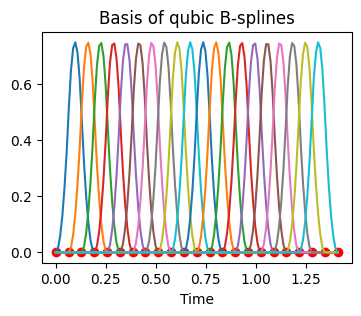

In [13]:
k = 2 #quartic bsplines (only 3 non zero bsplines simultaneously)

# Skip exactly 'k' on both sides to use purely uniform interior splines
skip_left = k
skip_right = k
n = num_bspln + skip_left + skip_right  # Total knots required = 24

m = n - k  # Total uniform intervals = 22

T_ns_hw = m * delta_ns
T_us_hw = T_ns_hw / 1000.0

time_start = 0.0
time_end = T_us_hw

# A degree k B-spline spans exactly k+1 intervals
L_ns = (k + 1) * delta_ns  

t_drive = T_us_hw






print("--- Pulse Properties ---")
print(f"B-spline Degree (k)     : {k}")
print(f"Grid step (delta_ns)    : {delta_ns} ns")
print(f"Single pulse length     : {L_ns} ns")
print(f"Total sequence duration : {T_ns_hw} ns ({T_us_hw} us)")
print(f"Max overlapping pulses  : {k + 1}")
print("------------------------")
assert L_ns % 4 == 0, "Pulse length is not a multiple of 4 ns!"



# build the bspline basis
t_drive_edges = jnp.linspace(0, t_drive, ndt_drive + 1)
t_drive_mids = (t_drive_edges[1:] + t_drive_edges[:-1]) / 2
t_drive_intvs = t_drive_edges[1:] - t_drive_edges[:-1]

bspline_builder = setup_bspline_builder(0, t_drive_edges[-1], n, k, skip_left, skip_right)

bsplns_mids = bspline_builder(t_drive_mids)
bsplns_edges = bspline_builder(t_drive_edges)

knots = bknots_on_interval(0, t_drive_edges[-1], n, k)
knots = np.unique(knots)

# TEST
fig, ax = plt.subplots(figsize=(4, 3))

for i in range(bsplns_edges.shape[0]):
    ax.plot(t_drive_edges, bsplns_edges[i])
        
ax.scatter(knots, np.zeros_like(knots), color="red");   
ax.set_xlabel("Time");
ax.set_title("Basis of qubic B-splines");


## Time step  
- 1) Measurement projection + qubit reset + readout backaction
- 2) Fidelity
- 3) Idling (decay and self Kerr)
- 4) RNN interrogation
- 5) Control with decay

In [14]:
def make_time_step(N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle, psi_target_cav):
    fidelity_cav = make_fidelity_cav(psi_target_cav)
    idle_cav = make_idle_cav(N_cav, t1_qub, t2_qub, t1_cav, t_idle)
    dt_idle = t_drive_intvs[0]
    drive = make_drive_with_relax(N_cav, chi,t1_qub, t2_qub, t1_cav,dt_idle)
    
    def time_step(key, rho, flax_state, params, carry):
        meas_out, prob, rho = measure_sz(key, rho,sigma_theta_e_deg=sigma_e_deg, sigma_theta_g_deg=sigma_g_deg)
        fid = fidelity_cav(rho)
        rho = idle_cav(rho)
        rnn_inp = jnp.array([meas_out], dtype=float)
        carry, ctrl_coeffs = apply_nn(flax_state, params, carry, rnn_inp)
        es_qub, es_cav = ctrl_from_coeffs(ctrl_coeffs, bsplns_mids)
        rho = drive(rho, es_qub, es_cav, t_drive_intvs)  
        return rho, carry, fid, meas_out, prob
    
    return time_step

## Trajectory

In [15]:
def make_trajectory(N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle, psi_target_cav):
    time_step = make_time_step(N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle, psi_target_cav)
    
    def trajectory(key, flax_state, params, num_time_steps):
        
        def f(scan_carry, _):
            key, rho, carry = scan_carry
            key, subkey = jax.random.split(key)
            rho, carry, fid, meas_out, prob = time_step(subkey, rho, flax_state, params, carry)
            y = fid, meas_out, prob
            scan_carry = key, rho, carry
            return scan_carry, y
        
        key1, key2 = jax.random.split(key)
        carry = init_carry(key1, rec_features, inp_shape)
        psi_init = tensor(basis(2), psi_target_cav)
        # psi_init = tensor(basis(2), basis(N_cav)) # alternative to make it learn to prepare the state from 0 
        scan_carry = key2, psi_init @ hconj(psi_init), carry
        _, ys = jax.lax.scan(f, scan_carry, length=num_time_steps)
        return ys
    
    return trajectory

## Trajectory with reward gradients

In [16]:
def make_trajectory_with_rewgrad(N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle, psi_target_cav):
    
    trajectory = make_trajectory(N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle, psi_target_cav)
    
    def trajectory_with_rewgrad(key, flax_state, num_time_steps):
    
        def func(params):
            traj_out = trajectory(key, flax_state, params, num_time_steps)
            fid, meas_out, prob = traj_out
            # rew = -jnp.log(1 - fid.mean())
            # log_prob = jnp.log(prob).sum()
            # return rew + jax.lax.stop_gradient(rew) * log_prob, traj_out
    
            eps = 1e-8

            fid_mean = jnp.real(fid.mean())
            fid_mean = jnp.clip(fid_mean, 0.0, 1.0 - eps)

            rew = -jnp.log(1.0 - fid_mean)

            prob_safe = jnp.clip(prob, eps, 1.0)
            log_prob = jnp.log(prob_safe).sum()

            return rew + jax.lax.stop_gradient(rew) * log_prob, traj_out


        grad_func = jax.grad(func, has_aux=True)
        rewgrad, traj_out = grad_func(flax_state.params)
        return rewgrad, traj_out
    
    return trajectory_with_rewgrad

## Train on batch

In [17]:
def make_train_on_batch(
        N_cav, chi,
        t1_qub, t2_qub, t1_cav, t_idle,
        psi_target_cav,
        batch_size, num_time_steps
    ):
    
    trajectory_with_rewgrad = make_trajectory_with_rewgrad(
        N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle, psi_target_cav
    )
    
    trajectory_with_rewgrad_vec = jax.vmap(
            trajectory_with_rewgrad, in_axes=(0, None, None)
        )
    
    @jax.jit
    def train_on_batch(key, flax_state):
        keys = jax.random.split(key, batch_size)
        rewgrad, traj_out = trajectory_with_rewgrad_vec(keys, flax_state, num_time_steps)
        lossgrad = jax.tree.map(lambda x: -x.mean(axis=0), rewgrad)
        flax_state = flax_state.apply_gradients(grads=lossgrad) 
        return flax_state, traj_out
    
    return train_on_batch

## Test on batch

In [18]:
def make_test_on_batch(
        N_cav, chi,
        t1_qub, t2_qub, t1_cav, t_idle,
        psi_target_cav,
        batch_size, num_time_steps
    ):
    
    trajectory = make_trajectory(
        N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle, psi_target_cav
    )
    
    trajectory_vec = jax.vmap(
            trajectory, in_axes=(0, None, None, None)
        )
    
    @jax.jit
    def test_on_batch(key, flax_state):
        keys = jax.random.split(key, batch_size)
        traj_out = trajectory_vec(keys, flax_state, flax_state.params, num_time_steps)
        return traj_out
    
    return test_on_batch

# Run the learning of the NN

In [19]:
mean_fids_train = []

In [20]:
num_time_steps_train = 32
num_time_steps_test = 150 
batch_size = 32 #number of different trajectories

In [21]:
train_on_batch = make_train_on_batch(
    N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle, psi_target_cav, batch_size, num_time_steps_train)

test_on_batch = make_test_on_batch(
    N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle, psi_target_cav, batch_size, num_time_steps_test)

#### note on learning rate

0.0003 seems good for small NN (i.e. dense_features = [160, 160])

0.00012 seems good for bigger NN (i.e. dense_features = [160,180,160])



In [22]:
init_lr = 0.000400
final_lr= 0.000010

constant_steps = 2000
decay_steps = 8000
total_steps = constant_steps + decay_steps

In [37]:
lr_schedule = optax.join_schedules(
    schedules=[
        optax.constant_schedule(init_lr),
        optax.linear_schedule(
            init_value=init_lr,
            end_value=final_lr,
            transition_steps=decay_steps,
        ),
        optax.constant_schedule(final_lr),
    ],
    boundaries=[
        constant_steps,
        constant_steps + decay_steps,
    ],
)

my_optimizer = optax.chain(
    optax.clip_by_global_norm(1.0),
    optax.adam(learning_rate=lr_schedule),
)

flax_state = flax_state.replace(
    tx=my_optimizer,
    opt_state=my_optimizer.init(flax_state.params),
)

for i in range(2*constant_steps + decay_steps):
    key, subkey = jax.random.split(key)
    flax_state, traj_out = train_on_batch(subkey, flax_state)
    fids, meas_outs, probs = traj_out
    mean_fid = fids.mean()
    mean_fids_train.append(mean_fid)

    print("i =",i,"    fid =",mean_fid)

i = 0     fid = 0.17251569
i = 1     fid = 0.17745648
i = 2     fid = 0.21731725
i = 3     fid = 0.22557437
i = 4     fid = 0.2254231
i = 5     fid = 0.23968019
i = 6     fid = 0.245014
i = 7     fid = 0.27959734
i = 8     fid = 0.28584608
i = 9     fid = 0.28592655
i = 10     fid = 0.28528327
i = 11     fid = 0.29907206
i = 12     fid = 0.30910963
i = 13     fid = 0.29483286
i = 14     fid = 0.30382943
i = 15     fid = 0.31403524
i = 16     fid = 0.3039654
i = 17     fid = 0.30894923
i = 18     fid = 0.3075758
i = 19     fid = 0.3052929
i = 20     fid = 0.32015443
i = 21     fid = 0.32949394
i = 22     fid = 0.33631206
i = 23     fid = 0.35341722
i = 24     fid = 0.36195946
i = 25     fid = 0.38550782
i = 26     fid = 0.38387525
i = 27     fid = 0.3960528
i = 28     fid = 0.4056487
i = 29     fid = 0.41206762
i = 30     fid = 0.432602
i = 31     fid = 0.4292906
i = 32     fid = 0.43962064
i = 33     fid = 0.41519982
i = 34     fid = 0.40694958
i = 35     fid = 0.39759868
i = 36     fi

In [38]:
i = 0
mean_fid=0
while mean_fid<0.915:
    i+=1
    key, subkey = jax.random.split(key)
    flax_state, traj_out = train_on_batch(subkey, flax_state)
    fids, meas_outs, probs = traj_out
    mean_fid = fids.mean()
    mean_fids_train.append(mean_fid)

    print("i =",i,"    fid =",mean_fid)

i = 1     fid = 0.8951393
i = 2     fid = 0.9092603
i = 3     fid = 0.8998132
i = 4     fid = 0.89672315
i = 5     fid = 0.8911849
i = 6     fid = 0.8955367
i = 7     fid = 0.9007937
i = 8     fid = 0.891984
i = 9     fid = 0.8883296
i = 10     fid = 0.91659415


12032


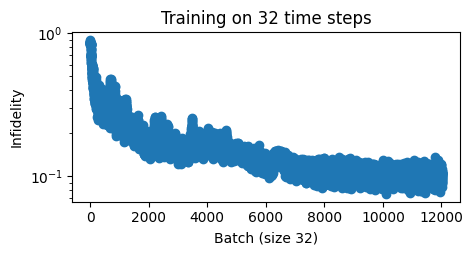

In [39]:
fig, ax = plt.subplots(figsize=(5, 2.2))

ff = jnp.array(mean_fids_train)

ax.scatter(jnp.arange(len(mean_fids_train)), 1 - ff);
ax.set_xlabel(f"Batch (size {batch_size})");
ax.set_ylabel("Infidelity");
ax.set_title(f"Training on {num_time_steps_train} time steps");
ax.set_yscale("log");
print(len(mean_fids_train))

# Save trained NN

In [ ]:
from datetime import datetime
from zoneinfo import ZoneInfo
save_name = "fg_trained/fock2"
comment = ""

timestamp = datetime.now(ZoneInfo("Europe/Paris")).strftime("%Y%m%d_%H%M")
run_folder = Path(save_name).resolve() / timestamp
run_folder.mkdir(parents=True, exist_ok=True)

In [28]:
from pathlib import Path
import shutil
import json
import numpy as np
import orbax.checkpoint as ocp

def save_flax_params_to_orbax(fld, state, *, step=1):
    ckpt_path = Path(fld).resolve() / "params_only" / str(step)
    ckpt_path.parent.mkdir(parents=True, exist_ok=True)

    if ckpt_path.exists():
        shutil.rmtree(ckpt_path)

    ckptr = ocp.Checkpointer(ocp.StandardCheckpointHandler())
    ckptr.save(
        ckpt_path,
        args=ocp.args.StandardSave(state.params),
    )

    print(f"Saved NN params to: {ckpt_path}")


def scalar(x):
    return float(np.asarray(x))


metadata = {
    "timestamp": timestamp,
    "comment": comment,
    "save_name": save_name,
    "run_folder": str(run_folder),

    "parameters": {
        "N_cav": int(N_cav),
        "ndt_drive": int(ndt_drive),
        "t_idle_us": scalar(t_idle),
        "sigma_e_deg": scalar(sigma_e_deg),
        "sigma_g_deg": scalar(sigma_g_deg),
        "readout_length_ns": int(readout_lenght_ns),

        "chi": scalar(chi),
        "chi_over_2pi_MHz": scalar(chi / (2 * np.pi)),
        "Kc_g": scalar(K_cg),
        "Kc_g_over_2pi_MHz": scalar(K_cg / (2 * np.pi)),
        "Kc_e": scalar(K_ce),
        "Kc_e_over_2pi_MHz": scalar(K_ce / (2 * np.pi)),

        "t1_qub_us": scalar(t1_qub),
        "t2_qub_us": scalar(t2_qub),
        "t1_cav_us": scalar(t1_cav),
    },

    "training": {
        "batch_size": int(batch_size),
        "num_time_steps_train": int(num_time_steps_train),
        "num_time_steps_test": int(num_time_steps_test),

        "init_lr": scalar(init_lr),
        "final_lr": scalar(final_lr),
        "constant_steps": int(constant_steps),
        "decay_steps": int(decay_steps),
        "total_steps": int(total_steps),

        "num_mean_fids_train": len(mean_fids_train),
        # "final_mean_fid_train": scalar(mean_fids_train[-1]),
        "mean_fids_train": [scalar(fid) for fid in mean_fids_train],
    },
}

metadata_path = run_folder / "metadata.json"
with metadata_path.open("w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

save_flax_params_to_orbax(run_folder, flax_state, step=1)

print(f"Saved metadata to: {metadata_path}")
print(f"Run folder: {run_folder}")

Saved NN params to: /home/user/python_experiments/train_feedback_grape/fg_trained/fock2/20260703_1015/params_only/1
Saved metadata to: /home/user/python_experiments/train_feedback_grape/fg_trained/fock2/20260703_1015/metadata.json
Run folder: /home/user/python_experiments/train_feedback_grape/fg_trained/fock2/20260703_1015


In [29]:
# Save NN weights in C++ compatible format in the timestamped run folder
import os
import struct
import numpy as np

def save_cpp_weights(fld, state):
    abs_path = os.path.abspath(fld)
    os.makedirs(abs_path, exist_ok=True)

    out_file = os.path.join(abs_path, "weights.bin")

    p = state.params

    arrays = [
        # GRU reset gate
        np.asarray(p["GRUCell_0"]["ir"]["kernel"], dtype=np.float32),
        np.asarray(p["GRUCell_0"]["ir"]["bias"], dtype=np.float32),
        np.asarray(p["GRUCell_0"]["hr"]["kernel"], dtype=np.float32),

        # GRU update gate
        np.asarray(p["GRUCell_0"]["iz"]["kernel"], dtype=np.float32),
        np.asarray(p["GRUCell_0"]["iz"]["bias"], dtype=np.float32),
        np.asarray(p["GRUCell_0"]["hz"]["kernel"], dtype=np.float32),

        # GRU candidate gate
        np.asarray(p["GRUCell_0"]["in"]["kernel"], dtype=np.float32),
        np.asarray(p["GRUCell_0"]["in"]["bias"], dtype=np.float32),
        np.asarray(p["GRUCell_0"]["hn"]["kernel"], dtype=np.float32),

        # MLP: 80 -> 160
        np.asarray(p["Dense_0"]["kernel"], dtype=np.float32),
        np.asarray(p["Dense_0"]["bias"], dtype=np.float32),

        # MLP: 160 -> 160
        np.asarray(p["Dense_1"]["kernel"], dtype=np.float32),
        np.asarray(p["Dense_1"]["bias"], dtype=np.float32),

        # MLP: 160 -> 80
        np.asarray(p["Dense_2"]["kernel"], dtype=np.float32),
        np.asarray(p["Dense_2"]["bias"], dtype=np.float32),
    ]

    print("Saving arrays:")
    for i, a in enumerate(arrays):
        print(f"  array {i:2d}: shape = {a.shape}")

    with open(out_file, "wb") as f:
        f.write(b"GRUCPP01")
        f.write(struct.pack("i", len(arrays)))

        for a in arrays:
            a = np.ascontiguousarray(a, dtype=np.float32)

            f.write(struct.pack("i", a.ndim))
            for s in a.shape:
                f.write(struct.pack("i", s))

            f.write(a.tobytes())

    print(f"\nSaved C++ weights to {out_file}")


save_cpp_weights(run_folder, flax_state)

Saving arrays:
  array  0: shape = (1, 80)
  array  1: shape = (80,)
  array  2: shape = (80, 80)
  array  3: shape = (1, 80)
  array  4: shape = (80,)
  array  5: shape = (80, 80)
  array  6: shape = (1, 80)
  array  7: shape = (80,)
  array  8: shape = (80, 80)
  array  9: shape = (80, 160)
  array 10: shape = (160,)
  array 11: shape = (160, 160)
  array 12: shape = (160,)
  array 13: shape = (160, 80)
  array 14: shape = (80,)

Saved C++ weights to /home/user/python_experiments/train_feedback_grape/fg_trained/fock2/20260703_1015/weights.bin


# plot trajectories

In [26]:
key, subkey = jax.random.split(key)
traj_out = test_on_batch(subkey, flax_state)
fids, meas_outs, probs = traj_out

2026-07-03 10:15:55.641906: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-07-03 10:15:55.641943: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-07-03 10:15:55.641954: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-07-03 10:15:55.641963: W external/xla/xla/service/gpu/au

nb +1 meas : 85.3125%


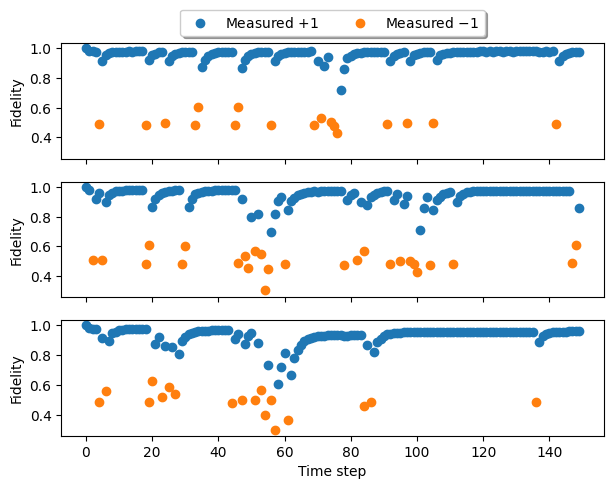

In [30]:
test_indx = [0, 1, 2]

fig, axes = plt.subplots(len(test_indx), 1, figsize=(7, 1.7 * len(test_indx)), sharex=True, sharey=True)

for ax, ti in zip(axes, test_indx):
    f = fids[ti]
    m = meas_outs[ti]
    arng = jnp.arange(len(f))
    ax.scatter(arng[m==1], f[m==1], label=r"Measured $+1$");
    ax.scatter(arng[m==-1], f[m==-1], label=r"Measured $-1$");
    ax.set_ylabel("Fidelity");
    
axes[0].legend(loc='upper center', bbox_to_anchor=(0.5, 1.35),
          fancybox=True, shadow=True, ncol=5);
ax.set_xlabel("Time step");
ax.set_title("");
plt.savefig(str(run_folder/timestamp)+"trajectories.png")

print(f"nb +1 meas : {100*(np.mean(meas_outs)+1)/2}%")

# Calculate mean trajectory

### simulate 2000 trajectories and average cavity density matrices

In [31]:
sim_feedback_steps_list = np.array([0, 3, 5, 10, 25, 50, 100], dtype=int)
sim_ntraj = 2000
sim_batch_size = 50
sim_n_batches = sim_ntraj // sim_batch_size
sim_max_steps = int(np.max(sim_feedback_steps_list))
sim_feedback_steps_all = np.arange(sim_max_steps + 1)

time_step_wigner_sim = make_time_step(
    N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle, psi_target_cav
)


def sim_one_wigner_trajectory(key, flax_state, params):
    key1, key2 = jax.random.split(key)
    carry_nn = init_carry(key1, rec_features, inp_shape)

    psi_init = tensor(basis(2), psi_target_cav)
    rho = psi_init @ hconj(psi_init)

    rho_cav = rho[:N_cav, :N_cav] + rho[N_cav:, N_cav:]
    pre_e = jnp.real(jnp.trace(rho[N_cav:, N_cav:]))

    snap_rhos = jnp.zeros((sim_max_steps + 1, N_cav, N_cav), dtype=rho.dtype)
    snap_pre_e = jnp.zeros((sim_max_steps + 1,), dtype=float)

    snap_rhos = snap_rhos.at[0].set(rho_cav)
    snap_pre_e = snap_pre_e.at[0].set(pre_e)

    def f(scan_carry, i):
        key, rho, carry_nn, snap_rhos, snap_pre_e = scan_carry
        key, subkey = jax.random.split(key)

        rho, carry_nn, fid, meas_out, prob = time_step_wigner_sim(
            subkey, rho, flax_state, params, carry_nn
        )

        rho_cav = rho[:N_cav, :N_cav] + rho[N_cav:, N_cav:]
        pre_e = jnp.real(jnp.trace(rho[N_cav:, N_cav:]))

        snap_rhos = snap_rhos.at[i + 1].set(rho_cav)
        snap_pre_e = snap_pre_e.at[i + 1].set(pre_e)

        return (key, rho, carry_nn, snap_rhos, snap_pre_e), None

    (_, _, _, snap_rhos, snap_pre_e), _ = jax.lax.scan(
        f,
        (key2, rho, carry_nn, snap_rhos, snap_pre_e),
        jnp.arange(sim_max_steps),
    )

    return snap_rhos, snap_pre_e


@jax.jit
def sim_wigner_batch(key, flax_state):
    keys = jax.random.split(key, sim_batch_size)
    return jax.vmap(sim_one_wigner_trajectory, in_axes=(0, None, None))(
        keys, flax_state, flax_state.params
    )


rho_cav_sum = np.zeros((len(sim_feedback_steps_all), N_cav, N_cav), dtype=np.complex128)
pre_e_sum = np.zeros(len(sim_feedback_steps_all), dtype=float)

for ib in range(sim_n_batches):
    key, subkey = jax.random.split(key)
    rho_batch, pre_e_batch = sim_wigner_batch(subkey, flax_state)

    rho_cav_sum += np.asarray(rho_batch).sum(axis=0)
    pre_e_sum += np.asarray(pre_e_batch).sum(axis=0)

    print(f"sim batch {ib + 1}/{sim_n_batches}")

rho_cav_avg = rho_cav_sum / sim_ntraj
pre_wigner_e_probability = pre_e_sum / sim_ntraj

2026-07-03 10:17:27.139966: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-07-03 10:17:27.139997: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-07-03 10:17:27.140008: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-07-03 10:17:27.140016: W external/xla/xla/service/gpu/au

sim batch 1/40
sim batch 2/40
sim batch 3/40
sim batch 4/40
sim batch 5/40
sim batch 6/40
sim batch 7/40
sim batch 8/40
sim batch 9/40
sim batch 10/40
sim batch 11/40
sim batch 12/40
sim batch 13/40
sim batch 14/40
sim batch 15/40
sim batch 16/40
sim batch 17/40
sim batch 18/40
sim batch 19/40
sim batch 20/40
sim batch 21/40
sim batch 22/40
sim batch 23/40
sim batch 24/40
sim batch 25/40
sim batch 26/40
sim batch 27/40
sim batch 28/40
sim batch 29/40
sim batch 30/40
sim batch 31/40
sim batch 32/40
sim batch 33/40
sim batch 34/40
sim batch 35/40
sim batch 36/40
sim batch 37/40
sim batch 38/40
sim batch 39/40
sim batch 40/40


### compute Wigners and cosine similarities

In [32]:
import qutip as qt
from scipy.ndimage import gaussian_filter
alpha = np.linspace(-2.4, 2.4, 120)

def qutip_wigner_alpha(rho_cav):
    return 2.0 * qt.wigner(
        qt.Qobj(np.asarray(rho_cav), dims=[[N_cav], [N_cav]]),
        np.sqrt(2.0) * alpha,
        np.sqrt(2.0) * alpha,
    )

def cosine_similarity(w1, w2):
    w1 = np.asarray(w1, dtype=float)
    w2 = np.asarray(w2, dtype=float)
    mask = np.isfinite(w1) & np.isfinite(w2)

    v1 = w1[mask].ravel()
    v2 = w2[mask].ravel()
    nrm = np.sqrt(np.sum(v1 * v1) * np.sum(v2 * v2))

    return float(np.sum(v1 * v2) / nrm)

rho_target_cav = np.asarray(psi_target_cav @ hconj(psi_target_cav))
wigner_target = qutip_wigner_alpha(rho_target_cav)

wigner_sim_all = np.array([
    qutip_wigner_alpha(rho_cav_avg[i])
    for i in range(len(sim_feedback_steps_all))
])

cosine_sim_all = np.array([
    cosine_similarity(wigner_sim_all[i], wigner_target)
    for i in range(len(sim_feedback_steps_all))
])

cosine_sim_filtered_all = np.array([
    cosine_similarity(gaussian_filter(wigner_sim_all[i], sigma=1.5), wigner_target)
    for i in range(len(sim_feedback_steps_all))
])

wigner_sim = wigner_sim_all[sim_feedback_steps_list]
pre_wigner_e_probability_plot = pre_wigner_e_probability[sim_feedback_steps_list]
cosine_sim = cosine_sim_all[sim_feedback_steps_list]
cosine_sim_filtered = cosine_sim_filtered_all[sim_feedback_steps_list]

### reproduce the experimental-style figure and save it

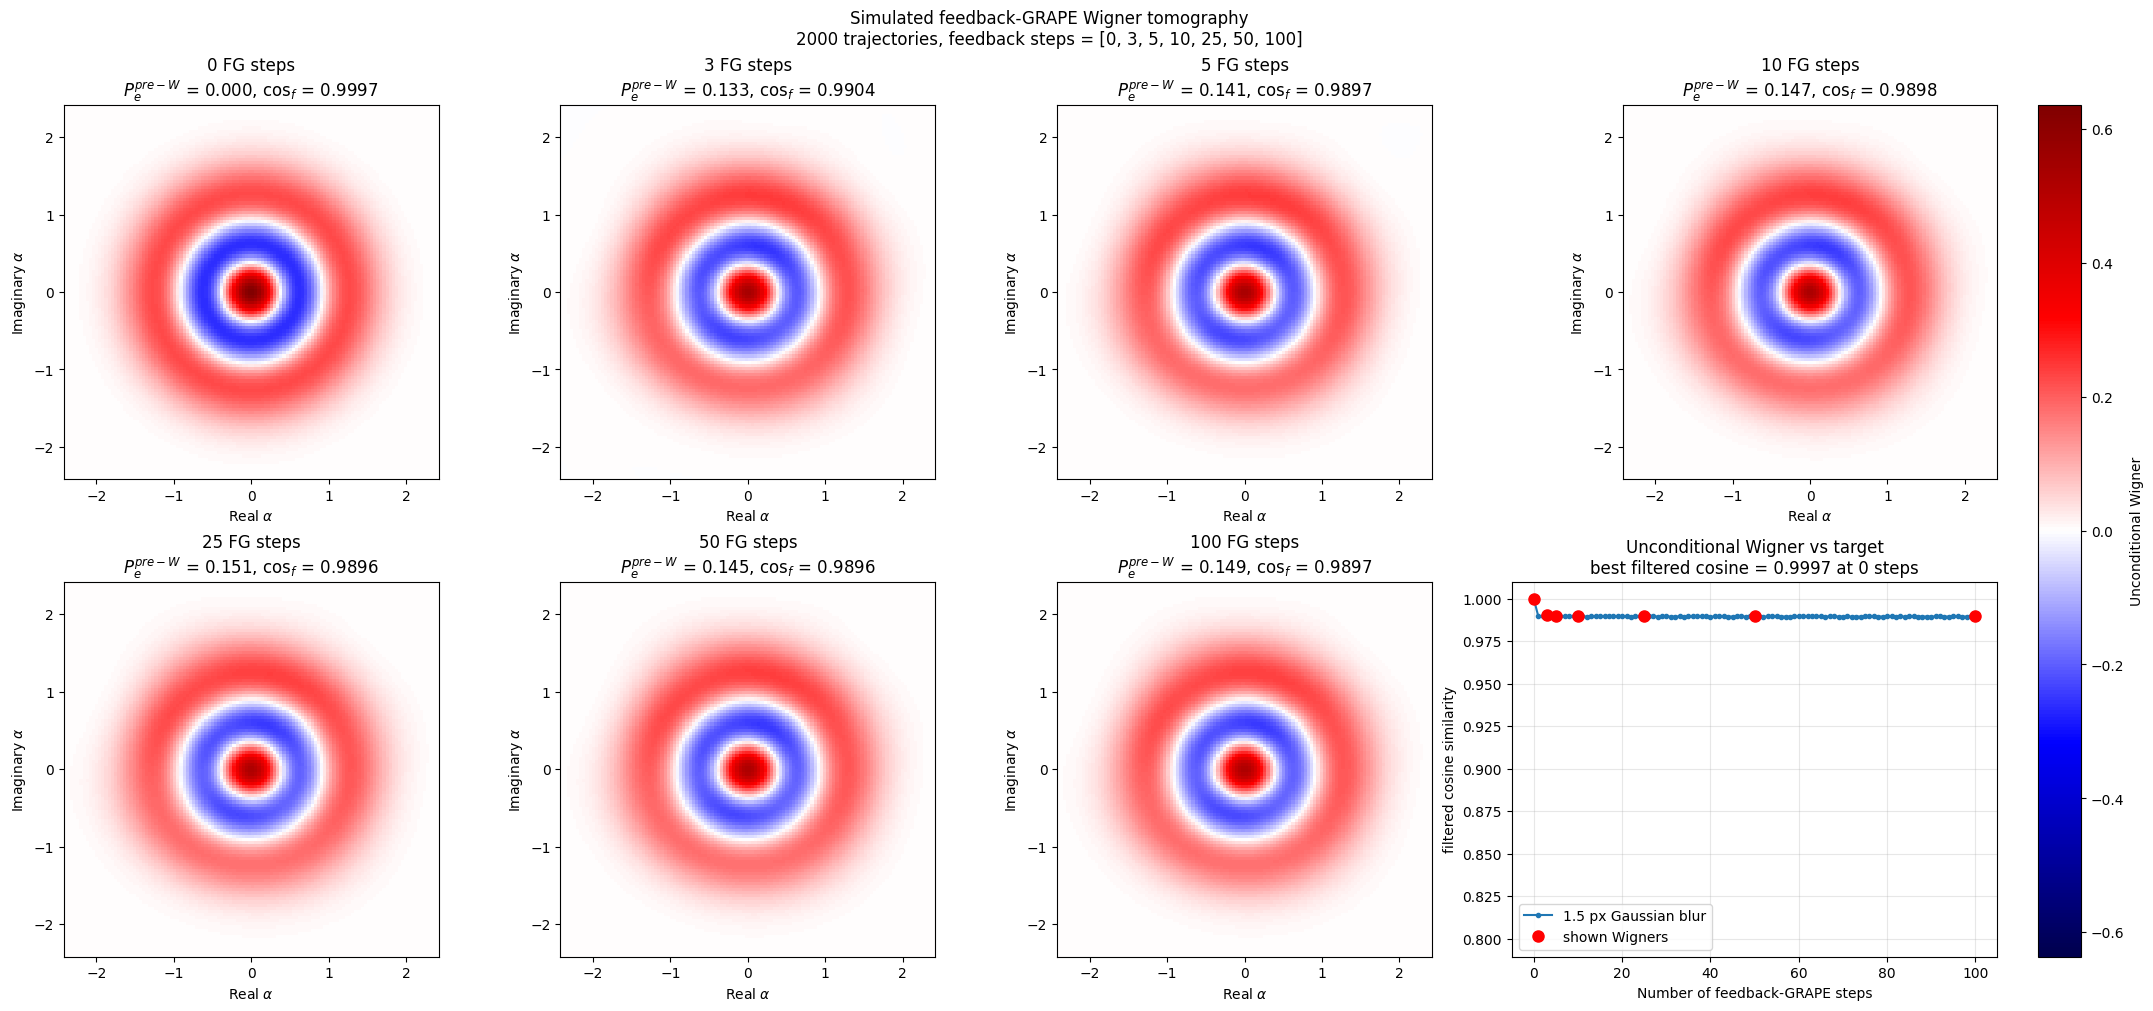

In [33]:
X, Y = np.meshgrid(alpha, alpha)
W_limit = 2.0 / np.pi

fig, axes = plt.subplots(2, 4, figsize=(22.0, 10.0), constrained_layout=True)
axes = np.ravel(axes)

meshes = []
for idx, n_steps_this in enumerate(sim_feedback_steps_list):
    im = axes[idx].pcolormesh(
        X,
        Y,
        wigner_sim[idx],
        cmap="seismic",
        vmin=-W_limit,
        vmax=W_limit,
        shading="auto",
    )
    axes[idx].set_xlabel(r"Real $\alpha$")
    axes[idx].set_ylabel(r"Imaginary $\alpha$")
    axes[idx].set_aspect("equal")
    axes[idx].set_title(
        f"{int(n_steps_this)} FG steps\n"
        rf"$P_e^{{pre-W}}$ = {pre_wigner_e_probability_plot[idx]:.3f}, "
        rf"cos$_f$ = {cosine_sim_filtered[idx]:.4f}"
    )
    meshes.append(im)

fig.colorbar(
    meshes[0],
    ax=axes[:len(sim_feedback_steps_list)],
    location="right",
    fraction=0.025,
    pad=0.02,
    label="Unconditional Wigner",
)

axes[-1].plot(
    sim_feedback_steps_all,
    cosine_sim_filtered_all,
    "o-",
    markersize=3,
    label="1.5 px Gaussian blur",
)
axes[-1].plot(
    sim_feedback_steps_list,
    cosine_sim_filtered,
    "o",
    markersize=8,
    color="red",
    label="shown Wigners",
)
axes[-1].set_xlabel("Number of feedback-GRAPE steps")
axes[-1].set_ylabel("filtered cosine similarity")
axes[-1].set_ylim(np.nanmin(cosine_sim_filtered_all) - 0.2, 1.01)
axes[-1].grid(True, alpha=0.3)
axes[-1].legend()

best_idx = int(np.nanargmax(cosine_sim_filtered_all))
axes[-1].set_title(
    "Unconditional Wigner vs target\n"
    f"best filtered cosine = {cosine_sim_filtered_all[best_idx]:.4f} "
    f"at {sim_feedback_steps_all[best_idx]} steps"
)

fig.suptitle(
    "Simulated feedback-GRAPE Wigner tomography\n"
    f"{sim_ntraj} trajectories, feedback steps = {sim_feedback_steps_list.tolist()}",
    fontsize=12,
)

plt.savefig(run_folder / "simulated_feedback_grape_wigners.png", dpi=200)
plt.savefig(run_folder / "simulated_feedback_grape_wigners.pdf")

np.savez(
    run_folder / "simulated_feedback_grape_wigners.npz",
    sim_feedback_steps_list=sim_feedback_steps_list,
    sim_feedback_steps_all=sim_feedback_steps_all,
    alpha=alpha,
    rho_cav_avg=rho_cav_avg,
    pre_wigner_e_probability_all=pre_wigner_e_probability,
    pre_wigner_e_probability=pre_wigner_e_probability_plot,
    wigner_sim_all=wigner_sim_all,
    wigner_sim=wigner_sim,
    wigner_target=wigner_target,
    cosine_sim_all=cosine_sim_all,
    cosine_sim_filtered_all=cosine_sim_filtered_all,
    cosine_sim=cosine_sim,
    cosine_sim_filtered=cosine_sim_filtered,
)

plt.show()

### estimate steady RNN memory, then simulate with this memory

In [ ]:
sim_ss_feedback_steps_list = np.array([0, 3, 5, 10, 25, 50, 100], dtype=int)
sim_ss_ntraj = 2000
sim_ss_batch_size = 50
sim_ss_n_batches = sim_ss_ntraj // sim_ss_batch_size
sim_ss_max_steps = int(np.max(sim_ss_feedback_steps_list))
sim_ss_feedback_steps_all = np.arange(sim_ss_max_steps + 1)

time_step_ss_sim = make_time_step(
    N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle, psi_target_cav
)


def sim_one_carry_after_100(key, flax_state, params):
    key1, key2 = jax.random.split(key)
    carry = init_carry(key1, rec_features, inp_shape)

    psi_init = tensor(basis(2), psi_target_cav)
    rho = psi_init @ hconj(psi_init)

    def f(scan_carry, _):
        key, rho, carry = scan_carry
        key, subkey = jax.random.split(key)

        rho, carry, fid, meas_out, prob = time_step_ss_sim(
            subkey, rho, flax_state, params, carry
        )

        return (key, rho, carry), None

    (_, _, carry), _ = jax.lax.scan(
        f,
        (key2, rho, carry),
        None,
        length=100,
    )

    return carry


@jax.jit
def sim_carry_after_100_batch(key, flax_state):
    keys = jax.random.split(key, sim_ss_batch_size)
    return jax.vmap(sim_one_carry_after_100, in_axes=(0, None, None))(
        keys, flax_state, flax_state.params
    )


carry_100_sum = np.zeros_like(
    np.asarray(init_carry(jax.random.key(0), rec_features, inp_shape)),
    dtype=np.float32,
)

for ib in range(sim_ss_n_batches):
    key, subkey = jax.random.split(key)
    carry_batch = sim_carry_after_100_batch(subkey, flax_state)

    carry_100_sum += np.asarray(carry_batch).sum(axis=0)

    print(f"steady-memory batch {ib + 1}/{sim_ss_n_batches}")

carry_100_mean = jnp.asarray(carry_100_sum / sim_ss_ntraj, dtype=jnp.float32)

np.save(run_folder / "rnn_carry_mean_after_100.npy", np.asarray(carry_100_mean))
print("carry_100_mean shape:", carry_100_mean.shape)
print("carry_100_mean norm:", float(jnp.linalg.norm(carry_100_mean)))


def sim_one_wigner_trajectory_ss_memory(key, flax_state, params, carry_init):
    carry_nn = carry_init

    psi_init = tensor(basis(2), psi_target_cav)
    rho = psi_init @ hconj(psi_init)

    rho_cav = rho[:N_cav, :N_cav] + rho[N_cav:, N_cav:]
    pre_e = jnp.real(jnp.trace(rho[N_cav:, N_cav:]))

    snap_rhos = jnp.zeros((sim_ss_max_steps + 1, N_cav, N_cav), dtype=rho.dtype)
    snap_pre_e = jnp.zeros((sim_ss_max_steps + 1,), dtype=jnp.float32)

    snap_rhos = snap_rhos.at[0].set(rho_cav)
    snap_pre_e = snap_pre_e.at[0].set(pre_e)

    def f(scan_carry, i):
        key, rho, carry_nn, snap_rhos, snap_pre_e = scan_carry
        key, subkey = jax.random.split(key)

        rho, carry_nn, fid, meas_out, prob = time_step_ss_sim(
            subkey, rho, flax_state, params, carry_nn
        )

        rho_cav = rho[:N_cav, :N_cav] + rho[N_cav:, N_cav:]
        pre_e = jnp.real(jnp.trace(rho[N_cav:, N_cav:]))

        snap_rhos = snap_rhos.at[i + 1].set(rho_cav)
        snap_pre_e = snap_pre_e.at[i + 1].set(pre_e)

        return (key, rho, carry_nn, snap_rhos, snap_pre_e), None

    (_, _, _, snap_rhos, snap_pre_e), _ = jax.lax.scan(
        f,
        (key, rho, carry_nn, snap_rhos, snap_pre_e),
        jnp.arange(sim_ss_max_steps),
    )

    return snap_rhos, snap_pre_e


@jax.jit
def sim_wigner_batch_ss_memory(key, flax_state, carry_init):
    keys = jax.random.split(key, sim_ss_batch_size)
    return jax.vmap(sim_one_wigner_trajectory_ss_memory, in_axes=(0, None, None, None))(
        keys, flax_state, flax_state.params, carry_init
    )


rho_cav_sum_ss = np.zeros(
    (len(sim_ss_feedback_steps_all), N_cav, N_cav),
    dtype=np.complex128,
)
pre_e_sum_ss = np.zeros(len(sim_ss_feedback_steps_all), dtype=float)

for ib in range(sim_ss_n_batches):
    key, subkey = jax.random.split(key)
    rho_batch_ss, pre_e_batch_ss = sim_wigner_batch_ss_memory(
        subkey, flax_state, carry_100_mean
    )

    rho_cav_sum_ss += np.asarray(rho_batch_ss).sum(axis=0)
    pre_e_sum_ss += np.asarray(pre_e_batch_ss).sum(axis=0)

    print(f"steady-memory sim batch {ib + 1}/{sim_ss_n_batches}")

rho_cav_avg_ss = rho_cav_sum_ss / sim_ss_ntraj
pre_wigner_e_probability_ss = pre_e_sum_ss / sim_ss_ntraj

steady-memory batch 1/40
steady-memory batch 2/40
steady-memory batch 3/40
steady-memory batch 4/40
steady-memory batch 5/40
steady-memory batch 6/40
steady-memory batch 7/40
steady-memory batch 8/40
steady-memory batch 9/40
steady-memory batch 10/40
steady-memory batch 11/40
steady-memory batch 12/40
steady-memory batch 13/40
steady-memory batch 14/40
steady-memory batch 15/40
steady-memory batch 16/40
steady-memory batch 17/40
steady-memory batch 18/40
steady-memory batch 19/40
steady-memory batch 20/40
steady-memory batch 21/40
steady-memory batch 22/40
steady-memory batch 23/40
steady-memory batch 24/40
steady-memory batch 25/40
steady-memory batch 26/40
steady-memory batch 27/40
steady-memory batch 28/40
steady-memory batch 29/40
steady-memory batch 30/40
steady-memory batch 31/40
steady-memory batch 32/40
steady-memory batch 33/40
steady-memory batch 34/40
steady-memory batch 35/40
steady-memory batch 36/40
steady-memory batch 37/40
steady-memory batch 38/40
steady-memory batch 3

### compute Wigners/cosines and plot comparison

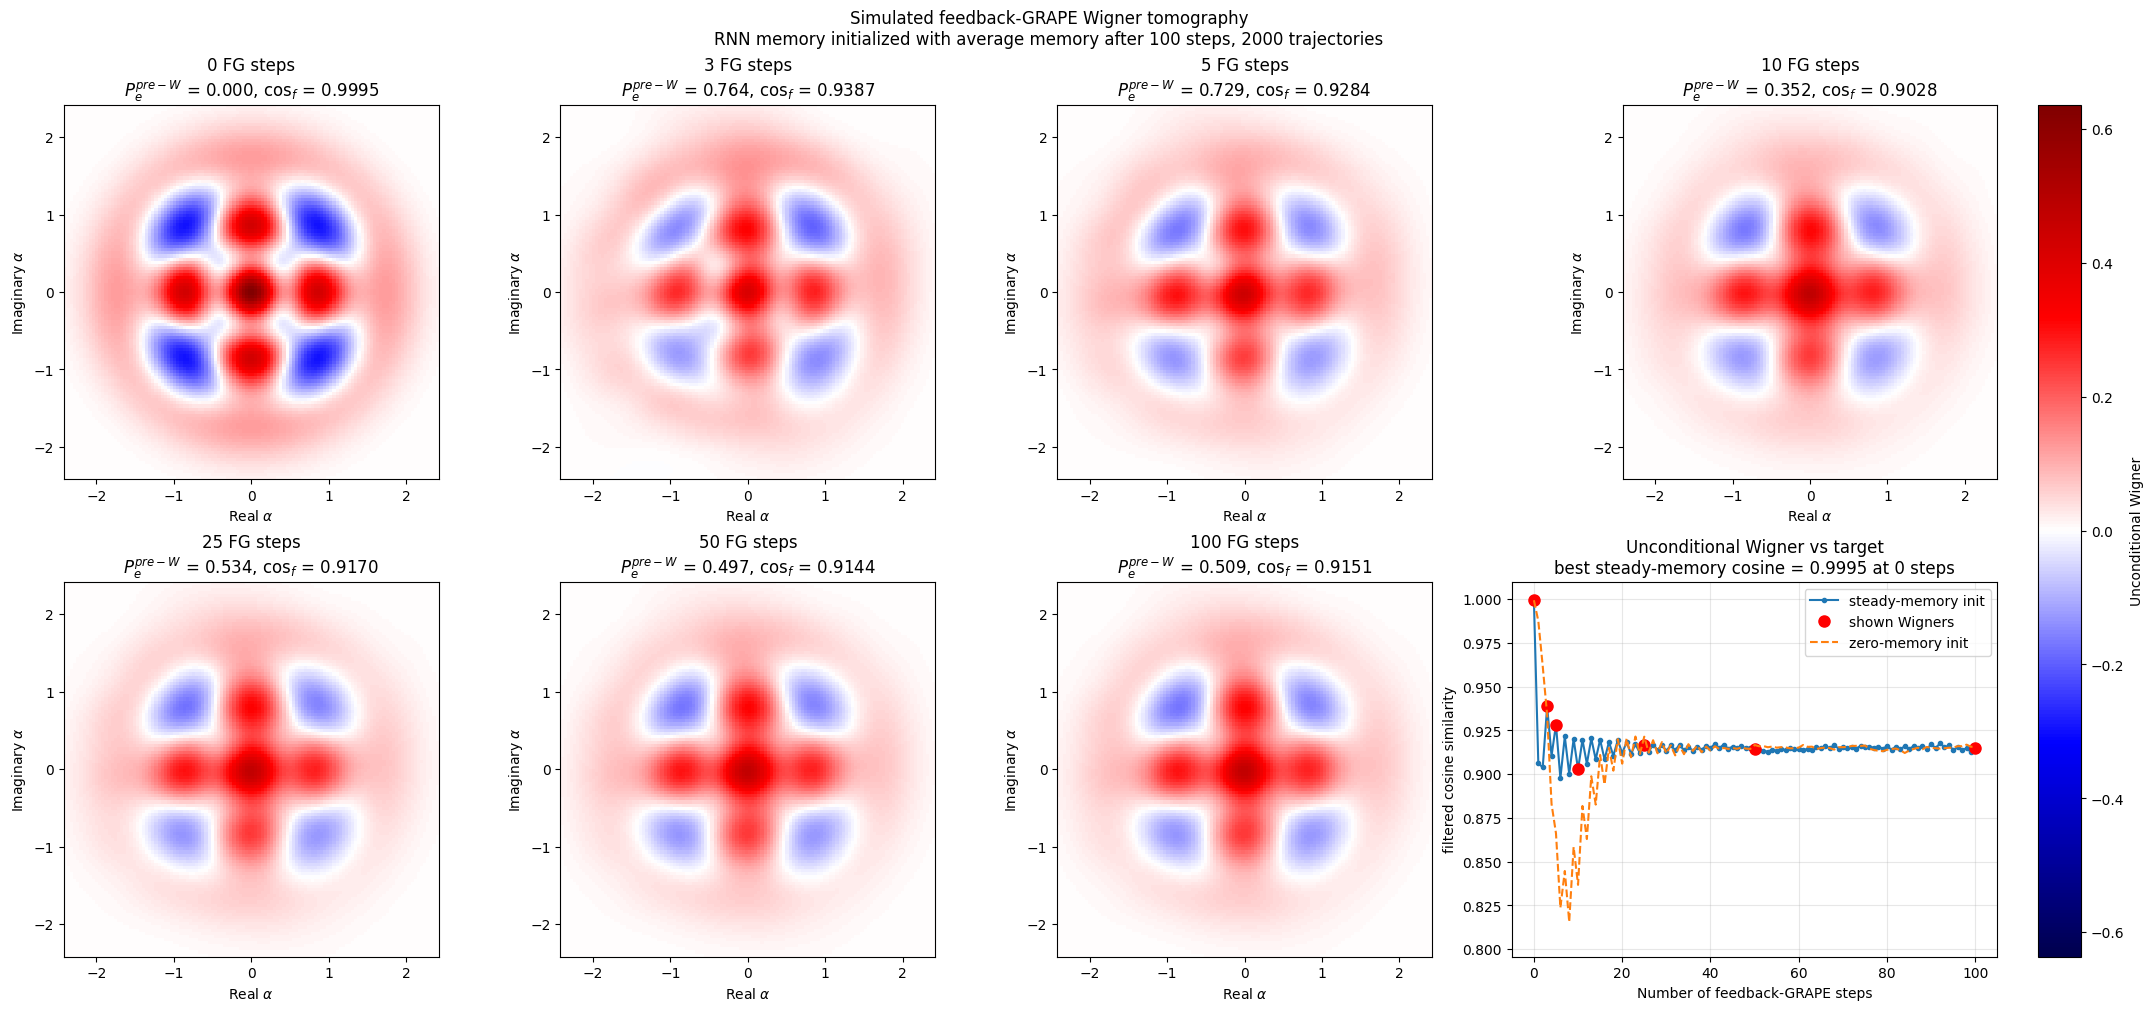

In [ ]:
alpha_ss = np.linspace(-2.4, 2.4, 120)

def qutip_wigner_alpha_ss(rho_cav):
    return 2.0 * qt.wigner(
        qt.Qobj(np.asarray(rho_cav), dims=[[N_cav], [N_cav]]),
        np.sqrt(2.0) * alpha_ss,
        np.sqrt(2.0) * alpha_ss,
    )

def cosine_similarity_ss(w1, w2):
    w1 = np.asarray(w1, dtype=float)
    w2 = np.asarray(w2, dtype=float)
    mask = np.isfinite(w1) & np.isfinite(w2)

    v1 = w1[mask].ravel()
    v2 = w2[mask].ravel()
    nrm = np.sqrt(np.sum(v1 * v1) * np.sum(v2 * v2))

    return float(np.sum(v1 * v2) / nrm)

rho_target_cav_ss = np.asarray(psi_target_cav @ hconj(psi_target_cav))
wigner_target_ss = qutip_wigner_alpha_ss(rho_target_cav_ss)

wigner_sim_all_ss = np.array([
    qutip_wigner_alpha_ss(rho_cav_avg_ss[i])
    for i in range(len(sim_ss_feedback_steps_all))
])

cosine_sim_all_ss = np.array([
    cosine_similarity_ss(wigner_sim_all_ss[i], wigner_target_ss)
    for i in range(len(sim_ss_feedback_steps_all))
])

cosine_sim_filtered_all_ss = np.array([
    cosine_similarity_ss(gaussian_filter(wigner_sim_all_ss[i], sigma=1.5), wigner_target_ss)
    for i in range(len(sim_ss_feedback_steps_all))
])

wigner_sim_ss = wigner_sim_all_ss[sim_ss_feedback_steps_list]
pre_wigner_e_probability_plot_ss = pre_wigner_e_probability_ss[sim_ss_feedback_steps_list]
cosine_sim_ss = cosine_sim_all_ss[sim_ss_feedback_steps_list]
cosine_sim_filtered_ss = cosine_sim_filtered_all_ss[sim_ss_feedback_steps_list]


X_ss, Y_ss = np.meshgrid(alpha_ss, alpha_ss)
W_limit = 2.0 / np.pi

fig, axes = plt.subplots(2, 4, figsize=(22.0, 10.0), constrained_layout=True)
axes = np.ravel(axes)

meshes = []
for idx, n_steps_this in enumerate(sim_ss_feedback_steps_list):
    im = axes[idx].pcolormesh(
        X_ss,
        Y_ss,
        wigner_sim_ss[idx],
        cmap="seismic",
        vmin=-W_limit,
        vmax=W_limit,
        shading="auto",
    )
    axes[idx].set_xlabel(r"Real $\alpha$")
    axes[idx].set_ylabel(r"Imaginary $\alpha$")
    axes[idx].set_aspect("equal")
    axes[idx].set_title(
        f"{int(n_steps_this)} FG steps\n"
        rf"$P_e^{{pre-W}}$ = {pre_wigner_e_probability_plot_ss[idx]:.3f}, "
        rf"cos$_f$ = {cosine_sim_filtered_ss[idx]:.4f}"
    )
    meshes.append(im)

fig.colorbar(
    meshes[0],
    ax=axes[:len(sim_ss_feedback_steps_list)],
    location="right",
    fraction=0.025,
    pad=0.02,
    label="Unconditional Wigner",
)

axes[-1].plot(
    sim_ss_feedback_steps_all,
    cosine_sim_filtered_all_ss,
    "o-",
    markersize=3,
    label="steady-memory init",
)

axes[-1].plot(
    sim_ss_feedback_steps_list,
    cosine_sim_filtered_ss,
    "o",
    markersize=8,
    color="red",
    label="shown Wigners",
)

axes[-1].plot(
    sim_feedback_steps_all,
    cosine_sim_filtered_all,
    "--",
    label="zero-memory init",
)

axes[-1].set_xlabel("Number of feedback-GRAPE steps")
axes[-1].set_ylabel("filtered cosine similarity")
axes[-1].set_ylim(
    min(np.nanmin(cosine_sim_filtered_all_ss), np.nanmin(cosine_sim_filtered_all)) - 0.02,
    1.01,
)
axes[-1].grid(True, alpha=0.3)
axes[-1].legend()

best_idx_ss = int(np.nanargmax(cosine_sim_filtered_all_ss))
axes[-1].set_title(
    "Unconditional Wigner vs target\n"
    f"best steady-memory cosine = {cosine_sim_filtered_all_ss[best_idx_ss]:.4f} "
    f"at {sim_ss_feedback_steps_all[best_idx_ss]} steps"
)

fig.suptitle(
    "Simulated feedback-GRAPE Wigner tomography\n"
    f"RNN memory initialized with average memory after 100 steps, "
    f"{sim_ss_ntraj} trajectories",
    fontsize=12,
)

plt.savefig(run_folder / "simulated_feedback_grape_wigners_steady_memory.png", dpi=200)
plt.savefig(run_folder / "simulated_feedback_grape_wigners_steady_memory.pdf")

np.savez(
    run_folder / "simulated_feedback_grape_wigners_steady_memory.npz",
    sim_ss_feedback_steps_list=sim_ss_feedback_steps_list,
    sim_ss_feedback_steps_all=sim_ss_feedback_steps_all,
    alpha=alpha_ss,
    carry_100_mean=np.asarray(carry_100_mean),
    rho_cav_avg_ss=rho_cav_avg_ss,
    pre_wigner_e_probability_all_ss=pre_wigner_e_probability_ss,
    pre_wigner_e_probability_ss=pre_wigner_e_probability_plot_ss,
    wigner_sim_all_ss=wigner_sim_all_ss,
    wigner_sim_ss=wigner_sim_ss,
    wigner_target_ss=wigner_target_ss,
    cosine_sim_all_ss=cosine_sim_all_ss,
    cosine_sim_filtered_all_ss=cosine_sim_filtered_all_ss,
    cosine_sim_ss=cosine_sim_ss,
    cosine_sim_filtered_ss=cosine_sim_filtered_ss,
)

plt.show()

# Measure sensitivity to parameter drifts

### qubit-drive amplitude sensitivity

2026-07-01 18:37:03.100839: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-07-01 18:37:03.100875: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-07-01 18:37:03.100893: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-07-01 18:37:03.100906: W external/xla/xla/service/gpu/au

qubit scale 0.90000 (-10.00 %) : mean fid = 0.654696, final fid = 0.641159
qubit scale 0.91000 (-9.00 %) : mean fid = 0.657157, final fid = 0.637882
qubit scale 0.92000 (-8.00 %) : mean fid = 0.673528, final fid = 0.672289
qubit scale 0.93000 (-7.00 %) : mean fid = 0.687089, final fid = 0.666620
qubit scale 0.94000 (-6.00 %) : mean fid = 0.696693, final fid = 0.669407
qubit scale 0.95000 (-5.00 %) : mean fid = 0.700208, final fid = 0.696679
qubit scale 0.96000 (-4.00 %) : mean fid = 0.703610, final fid = 0.686055
qubit scale 0.97000 (-3.00 %) : mean fid = 0.714193, final fid = 0.704219
qubit scale 0.98000 (-2.00 %) : mean fid = 0.723791, final fid = 0.697408
qubit scale 0.99000 (-1.00 %) : mean fid = 0.724583, final fid = 0.701053
qubit scale 1.00000 (+0.00 %) : mean fid = 0.726130, final fid = 0.692516
qubit scale 1.01000 (+1.00 %) : mean fid = 0.723574, final fid = 0.710803
qubit scale 1.02000 (+2.00 %) : mean fid = 0.716019, final fid = 0.703085
qubit scale 1.03000 (+3.00 %) : mean 

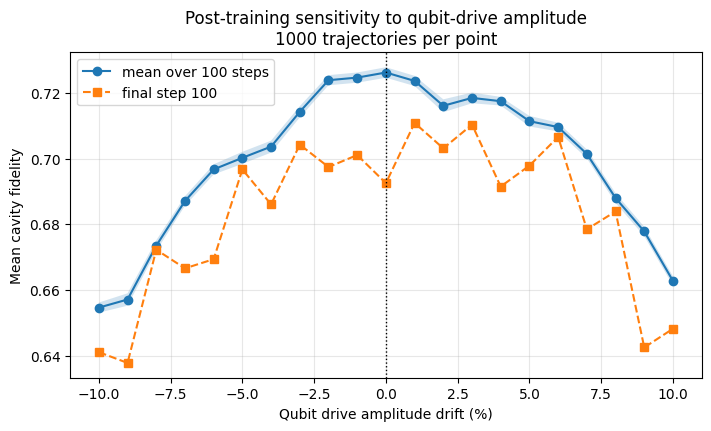

In [29]:
sens_ntraj = 1000
sens_num_steps = 100
sens_batch_size = 250

sens_scale_drifts = np.linspace(-0.1, 0.1, 21)
sens_scales = 1.0 + sens_scale_drifts

fidelity_cav_sens = make_fidelity_cav(psi_target_cav)
idle_cav_sens = make_idle_cav(N_cav, t1_qub, t2_qub, t1_cav, t_idle)
drive_sens = make_drive_with_relax(
    N_cav, chi, t1_qub, t2_qub, t1_cav, t_drive_intvs[0]
)


def sens_one_trajectory(key, flax_state, params, qub_scale, cav_scale):
    key1, key2 = jax.random.split(key)
    carry = init_carry(key1, rec_features, inp_shape)

    psi_init = tensor(basis(2), psi_target_cav)
    rho = psi_init @ hconj(psi_init)

    def f(scan_carry, _):
        key, rho, carry = scan_carry
        key, subkey = jax.random.split(key)

        meas_out, prob, rho = measure_sz(
            subkey,
            rho,
            sigma_theta_e_deg=sigma_e_deg,
            sigma_theta_g_deg=sigma_g_deg,
            kerr=add_kerr_during_readout,
        )

        rho = idle_cav_sens(rho)

        rnn_inp = jnp.array([meas_out], dtype=float)
        carry, ctrl_coeffs = apply_nn(flax_state, params, carry, rnn_inp)

        es_qub, es_cav = ctrl_from_coeffs(ctrl_coeffs, bsplns_mids)
        es_qub = qub_scale * es_qub
        es_cav = cav_scale * es_cav

        rho = drive_sens(rho, es_qub, es_cav, t_drive_intvs)

        fid_after = fidelity_cav_sens(rho)

        return (key, rho, carry), fid_after

    _, fids_after = jax.lax.scan(
        f,
        (key2, rho, carry),
        None,
        length=sens_num_steps,
    )

    return fids_after


@jax.jit
def sens_run_batch(key, flax_state, qub_scale, cav_scale):
    keys = jax.random.split(key, sens_batch_size)
    return jax.vmap(sens_one_trajectory, in_axes=(0, None, None, None, None))(
        keys,
        flax_state,
        flax_state.params,
        qub_scale,
        cav_scale,
    )


qub_scale_mean_fid = np.zeros(len(sens_scales))
qub_scale_final_fid = np.zeros(len(sens_scales))
qub_scale_sem_fid = np.zeros(len(sens_scales))

for i, scale in enumerate(sens_scales):
    key, subkey = jax.random.split(key)

    fids = np.asarray(
        sens_run_batch(
            subkey,
            flax_state,
            jnp.asarray(scale, dtype=jnp.float32),
            jnp.asarray(1.0, dtype=jnp.float32),
        )
    )

    fid_per_traj = np.mean(fids, axis=1)

    qub_scale_mean_fid[i] = np.mean(fid_per_traj)
    qub_scale_final_fid[i] = np.mean(fids[:, -1])
    qub_scale_sem_fid[i] = np.std(fid_per_traj) / np.sqrt(sens_ntraj)

    print(
        f"qubit scale {scale:.5f} "
        f"({100 * (scale - 1):+.2f} %) : "
        f"mean fid = {qub_scale_mean_fid[i]:.6f}, "
        f"final fid = {qub_scale_final_fid[i]:.6f}"
    )


fig, ax = plt.subplots(figsize=(7.0, 4.2), constrained_layout=True)

x_percent = 100 * (sens_scales - 1.0)

ax.plot(x_percent, qub_scale_mean_fid, "o-", label=f"mean over {sens_num_steps} steps")
ax.fill_between(
    x_percent,
    qub_scale_mean_fid - qub_scale_sem_fid,
    qub_scale_mean_fid + qub_scale_sem_fid,
    alpha=0.2,
)
ax.plot(x_percent, qub_scale_final_fid, "s--", label=f"final step {sens_num_steps}")

ax.axvline(0.0, color="k", linestyle=":", linewidth=1)
ax.set_xlabel("Qubit drive amplitude drift (%)")
ax.set_ylabel("Mean cavity fidelity")
ax.set_title(
    f"Post-training sensitivity to qubit-drive amplitude\n"
    f"{sens_ntraj} trajectories per point"
)
ax.grid(True, alpha=0.3)
ax.legend()

plt.savefig(run_folder / "sensitivity_qubit_drive_scale.png", dpi=200)
plt.savefig(run_folder / "sensitivity_qubit_drive_scale.pdf")

np.savez(
    run_folder / "sensitivity_qubit_drive_scale.npz",
    sens_scale_drifts=sens_scale_drifts,
    sens_scales=sens_scales,
    qub_scale_mean_fid=qub_scale_mean_fid,
    qub_scale_final_fid=qub_scale_final_fid,
    qub_scale_sem_fid=qub_scale_sem_fid,
    sens_ntraj=sens_ntraj,
    sens_num_steps=sens_num_steps,
)

plt.show()

### cavity-drive amplitude sensitivity

cavity scale 0.90000 (-10.00 %) : mean fid = 0.722284, final fid = 0.703441
cavity scale 0.91000 (-9.00 %) : mean fid = 0.721744, final fid = 0.710423
cavity scale 0.92000 (-8.00 %) : mean fid = 0.735794, final fid = 0.725647
cavity scale 0.93000 (-7.00 %) : mean fid = 0.732474, final fid = 0.720814
cavity scale 0.94000 (-6.00 %) : mean fid = 0.735780, final fid = 0.725845
cavity scale 0.95000 (-5.00 %) : mean fid = 0.734702, final fid = 0.723812
cavity scale 0.96000 (-4.00 %) : mean fid = 0.732011, final fid = 0.711456
cavity scale 0.97000 (-3.00 %) : mean fid = 0.730921, final fid = 0.728038
cavity scale 0.98000 (-2.00 %) : mean fid = 0.728131, final fid = 0.705113
cavity scale 0.99000 (-1.00 %) : mean fid = 0.723831, final fid = 0.717789
cavity scale 1.00000 (+0.00 %) : mean fid = 0.718108, final fid = 0.715924
cavity scale 1.01000 (+1.00 %) : mean fid = 0.721985, final fid = 0.714052
cavity scale 1.02000 (+2.00 %) : mean fid = 0.710202, final fid = 0.685528
cavity scale 1.03000 (+3

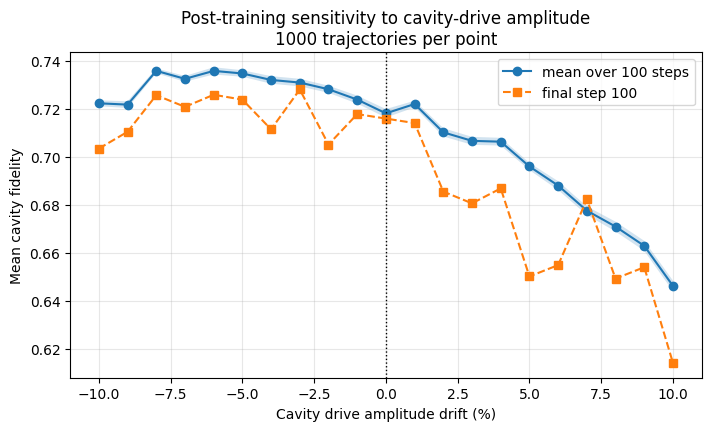

In [30]:
cav_scale_mean_fid = np.zeros(len(sens_scales))
cav_scale_final_fid = np.zeros(len(sens_scales))
cav_scale_sem_fid = np.zeros(len(sens_scales))

for i, scale in enumerate(sens_scales):
    key, subkey = jax.random.split(key)

    fids = np.asarray(
        sens_run_batch(
            subkey,
            flax_state,
            jnp.asarray(1.0, dtype=jnp.float32),
            jnp.asarray(scale, dtype=jnp.float32),
        )
    )

    fid_per_traj = np.mean(fids, axis=1)

    cav_scale_mean_fid[i] = np.mean(fid_per_traj)
    cav_scale_final_fid[i] = np.mean(fids[:, -1])
    cav_scale_sem_fid[i] = np.std(fid_per_traj) / np.sqrt(sens_ntraj)

    print(
        f"cavity scale {scale:.5f} "
        f"({100 * (scale - 1):+.2f} %) : "
        f"mean fid = {cav_scale_mean_fid[i]:.6f}, "
        f"final fid = {cav_scale_final_fid[i]:.6f}"
    )


fig, ax = plt.subplots(figsize=(7.0, 4.2), constrained_layout=True)

x_percent = 100 * (sens_scales - 1.0)

ax.plot(x_percent, cav_scale_mean_fid, "o-", label=f"mean over {sens_num_steps} steps")
ax.fill_between(
    x_percent,
    cav_scale_mean_fid - cav_scale_sem_fid,
    cav_scale_mean_fid + cav_scale_sem_fid,
    alpha=0.2,
)
ax.plot(x_percent, cav_scale_final_fid, "s--", label=f"final step {sens_num_steps}")

ax.axvline(0.0, color="k", linestyle=":", linewidth=1)
ax.set_xlabel("Cavity drive amplitude drift (%)")
ax.set_ylabel("Mean cavity fidelity")
ax.set_title(
    f"Post-training sensitivity to cavity-drive amplitude\n"
    f"{sens_ntraj} trajectories per point"
)
ax.grid(True, alpha=0.3)
ax.legend()

plt.savefig(run_folder / "sensitivity_cavity_drive_scale.png", dpi=200)
plt.savefig(run_folder / "sensitivity_cavity_drive_scale.pdf")

np.savez(
    run_folder / "sensitivity_cavity_drive_scale.npz",
    sens_scale_drifts=sens_scale_drifts,
    sens_scales=sens_scales,
    cav_scale_mean_fid=cav_scale_mean_fid,
    cav_scale_final_fid=cav_scale_final_fid,
    cav_scale_sem_fid=cav_scale_sem_fid,
    sens_ntraj=sens_ntraj,
    sens_num_steps=sens_num_steps,
)

plt.show()

### qubit-frequency detuning sweep

qubit detuning -0.1000 MHz : mean fid = 0.700994, final fid = 0.623913
qubit detuning -0.0950 MHz : mean fid = 0.703388, final fid = 0.706933
qubit detuning -0.0900 MHz : mean fid = 0.707721, final fid = 0.693269
qubit detuning -0.0850 MHz : mean fid = 0.713433, final fid = 0.732128
qubit detuning -0.0800 MHz : mean fid = 0.704686, final fid = 0.702457
qubit detuning -0.0750 MHz : mean fid = 0.709177, final fid = 0.694567
qubit detuning -0.0700 MHz : mean fid = 0.711583, final fid = 0.677083
qubit detuning -0.0650 MHz : mean fid = 0.712119, final fid = 0.678977
qubit detuning -0.0600 MHz : mean fid = 0.707119, final fid = 0.707887
qubit detuning -0.0550 MHz : mean fid = 0.711365, final fid = 0.659742
qubit detuning -0.0500 MHz : mean fid = 0.721490, final fid = 0.700660
qubit detuning -0.0450 MHz : mean fid = 0.722426, final fid = 0.721925
qubit detuning -0.0400 MHz : mean fid = 0.708990, final fid = 0.674237
qubit detuning -0.0350 MHz : mean fid = 0.723864, final fid = 0.722205
qubit 

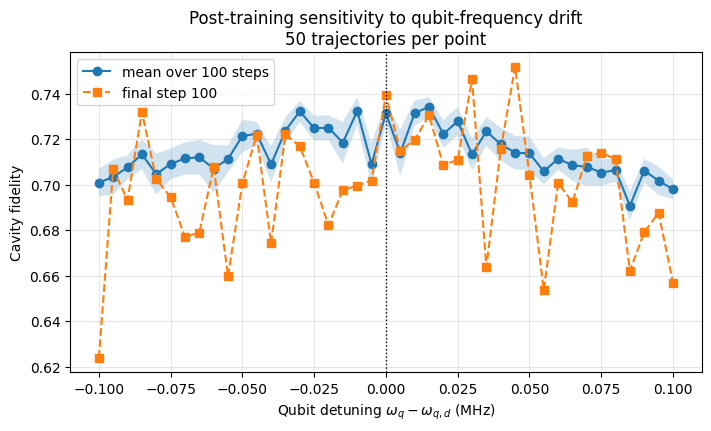

In [31]:
sens_det_ntraj = 50
sens_det_num_steps = 100
sens_det_batch_size = 50

sens_detuning_mhz = np.linspace(-0.1, 0.1, 41)
sens_detuning_radus = 2.0 * np.pi * sens_detuning_mhz

fidelity_det_sens = make_fidelity_cav(psi_target_cav)
drive_relax_dt_det = make_idle_dt(N_cav, t1_qub, t2_qub, t1_cav, t_drive_intvs[0])

g_det = basis(2)
rho_g_det = g_det @ hconj(g_det)


def make_cavity_idle_matrix_detuned(N_cav, t1_cav, t_idle, delta_c):
    a = destroy(N_cav)
    adag = hconj(a)

    H_kerr_cav = 0.5 * K_cg * adag @ adag @ a @ a
    H_det_cav = delta_c * adag @ a

    c_loss = a / jnp.sqrt(t1_cav)

    L_idle = liouv_hamiltonian(H_kerr_cav + H_det_cav)
    L_idle += liouv_relax_channel(c_loss)

    return jsp.linalg.expm(L_idle * t_idle)


def idle_cav_detuned(rho, idle_cav_matrix):
    rho_cav = rho[:N_cav, :N_cav]

    rho_cav_liouv = rho_cav.reshape(-1, 1)
    rho_cav_liouv = idle_cav_matrix @ rho_cav_liouv
    rho_cav = rho_cav_liouv.reshape((N_cav, N_cav))

    rho_out = tensor(rho_g_det, rho_cav)
    rho_out /= jnp.trace(rho_out)

    return rho_out


def build_drive_htree_detuned(N_cav, chi, e_qub, e_cav, delta_q, delta_c):
    a = tensor(identity(2), destroy(N_cav))
    adag = hconj(a)
    n_phot = adag @ a

    sigz = tensor(sigma.z, identity(N_cav))
    sigp = tensor(sigma.p, identity(N_cav))
    one = tensor(identity(2), identity(N_cav))

    proj_g = 0.5 * (one + sigz)
    proj_e = 0.5 * (one - sigz)

    H_disp = (chi / 2) * n_phot @ (one - sigz)

    kerr_op = adag @ adag @ a @ a
    H_kerr = 0.5 * (K_cg * proj_g + K_ce * proj_e) @ kerr_op

    H_det_qub = delta_q * proj_e
    H_det_cav = delta_c * n_phot

    H_drift = H_disp + H_kerr + H_det_qub + H_det_cav

    ht = [
        [H_drift, 1, 1, 0],
        [mu_qub * sigp, e_qub, 1, 1],
        [mu_cav * adag, 1j * jnp.conj(e_cav), 1, 1],
    ]

    return ht


def get_uevol_matrix_detuned(N_cav, chi, e_qub, e_cav, delta_q, delta_c, dt):
    htree = build_drive_htree_detuned(N_cav, chi, e_qub, e_cav, delta_q, delta_c)
    hmat = hmat_from_htree(htree)
    return evol_hdt_exp(hmat, dt)


def drive_with_relax_detuned(rho_init, es_qub, es_cav, dts, delta_q, delta_c):
    def f(rho, x):
        e_qub, e_cav, dt = x

        uevol = get_uevol_matrix_detuned(
            N_cav,
            chi,
            e_qub,
            e_cav,
            delta_q,
            delta_c,
            dt,
        )[0]

        rho = uevol @ rho @ hconj(uevol)
        rho = drive_relax_dt_det(rho)

        return rho, None

    rho_fin, _ = jax.lax.scan(f, rho_init, [es_qub, es_cav, dts])

    return rho_fin


def sens_det_one_trajectory(key, flax_state, params, delta_q, delta_c, idle_cav_matrix):
    key1, key2 = jax.random.split(key)
    carry = init_carry(key1, rec_features, inp_shape)

    psi_init = tensor(basis(2), psi_target_cav)
    rho = psi_init @ hconj(psi_init)

    def f(scan_carry, _):
        key, rho, carry = scan_carry
        key, subkey = jax.random.split(key)

        meas_out, prob, rho = measure_sz(
            subkey,
            rho,
            sigma_theta_e_deg=sigma_e_deg,
            sigma_theta_g_deg=sigma_g_deg,
            kerr=add_kerr_during_readout,
        )

        rho = idle_cav_detuned(rho, idle_cav_matrix)

        rnn_inp = jnp.array([meas_out], dtype=float)
        carry, ctrl_coeffs = apply_nn(flax_state, params, carry, rnn_inp)

        es_qub, es_cav = ctrl_from_coeffs(ctrl_coeffs, bsplns_mids)

        rho = drive_with_relax_detuned(
            rho,
            es_qub,
            es_cav,
            t_drive_intvs,
            delta_q,
            delta_c,
        )

        fid_after = fidelity_det_sens(rho)

        return (key, rho, carry), fid_after

    _, fids_after = jax.lax.scan(
        f,
        (key2, rho, carry),
        None,
        length=sens_det_num_steps,
    )

    return fids_after


@jax.jit
def sens_det_run_batch(key, flax_state, delta_q, delta_c, idle_cav_matrix):
    keys = jax.random.split(key, sens_det_batch_size)

    return jax.vmap(
        sens_det_one_trajectory,
        in_axes=(0, None, None, None, None, None),
    )(
        keys,
        flax_state,
        flax_state.params,
        delta_q,
        delta_c,
        idle_cav_matrix,
    )


qub_det_mean_fid = np.zeros(len(sens_detuning_mhz))
qub_det_final_fid = np.zeros(len(sens_detuning_mhz))
qub_det_sem_fid = np.zeros(len(sens_detuning_mhz))

idle_cav_matrix_no_cav_det = make_cavity_idle_matrix_detuned(
    N_cav,
    t1_cav,
    t_idle,
    jnp.asarray(0.0, dtype=jnp.float32),
)

for i, delta_q in enumerate(sens_detuning_radus):
    key, subkey = jax.random.split(key)

    fids = np.asarray(
        sens_det_run_batch(
            subkey,
            flax_state,
            jnp.asarray(delta_q, dtype=jnp.float32),
            jnp.asarray(0.0, dtype=jnp.float32),
            idle_cav_matrix_no_cav_det,
        )
    )

    fid_per_traj = np.mean(fids, axis=1)

    qub_det_mean_fid[i] = np.mean(fid_per_traj)
    qub_det_final_fid[i] = np.mean(fids[:, -1])
    qub_det_sem_fid[i] = np.std(fid_per_traj) / np.sqrt(sens_det_ntraj)

    print(
        f"qubit detuning {sens_detuning_mhz[i]:+.4f} MHz : "
        f"mean fid = {qub_det_mean_fid[i]:.6f}, "
        f"final fid = {qub_det_final_fid[i]:.6f}"
    )


fig, ax = plt.subplots(figsize=(7.0, 4.2), constrained_layout=True)

ax.plot(
    sens_detuning_mhz,
    qub_det_mean_fid,
    "o-",
    label=f"mean over {sens_det_num_steps} steps",
)
ax.fill_between(
    sens_detuning_mhz,
    qub_det_mean_fid - qub_det_sem_fid,
    qub_det_mean_fid + qub_det_sem_fid,
    alpha=0.2,
)
ax.plot(
    sens_detuning_mhz,
    qub_det_final_fid,
    "s--",
    label=f"final step {sens_det_num_steps}",
)

ax.axvline(0.0, color="k", linestyle=":", linewidth=1)
ax.set_xlabel(r"Qubit detuning $\omega_q - \omega_{q,d}$ (MHz)")
ax.set_ylabel("Cavity fidelity")
ax.set_title(
    f"Post-training sensitivity to qubit-frequency drift\n"
    f"{sens_det_ntraj} trajectories per point"
)
ax.grid(True, alpha=0.3)
ax.legend()

plt.savefig(run_folder / "sensitivity_qubit_frequency_detuning.png", dpi=200)
plt.savefig(run_folder / "sensitivity_qubit_frequency_detuning.pdf")

np.savez(
    run_folder / "sensitivity_qubit_frequency_detuning.npz",
    sens_detuning_mhz=sens_detuning_mhz,
    sens_detuning_radus=sens_detuning_radus,
    qub_det_mean_fid=qub_det_mean_fid,
    qub_det_final_fid=qub_det_final_fid,
    qub_det_sem_fid=qub_det_sem_fid,
    sens_det_ntraj=sens_det_ntraj,
    sens_det_num_steps=sens_det_num_steps,
)

plt.show()

### cavity-frequency detuning sweep

cavity detuning -0.1000 MHz : mean fid = 0.294038, final fid = 0.301209
cavity detuning -0.0950 MHz : mean fid = 0.263379, final fid = 0.245937
cavity detuning -0.0900 MHz : mean fid = 0.217110, final fid = 0.201665
cavity detuning -0.0850 MHz : mean fid = 0.418863, final fid = 0.406058
cavity detuning -0.0800 MHz : mean fid = 0.337647, final fid = 0.356400
cavity detuning -0.0750 MHz : mean fid = 0.254510, final fid = 0.213003
cavity detuning -0.0700 MHz : mean fid = 0.200682, final fid = 0.177986
cavity detuning -0.0650 MHz : mean fid = 0.271479, final fid = 0.251813
cavity detuning -0.0600 MHz : mean fid = 0.237488, final fid = 0.241409
cavity detuning -0.0550 MHz : mean fid = 0.250964, final fid = 0.233736
cavity detuning -0.0500 MHz : mean fid = 0.215813, final fid = 0.169222
cavity detuning -0.0450 MHz : mean fid = 0.264455, final fid = 0.245625
cavity detuning -0.0400 MHz : mean fid = 0.282798, final fid = 0.226890
cavity detuning -0.0350 MHz : mean fid = 0.254478, final fid = 0

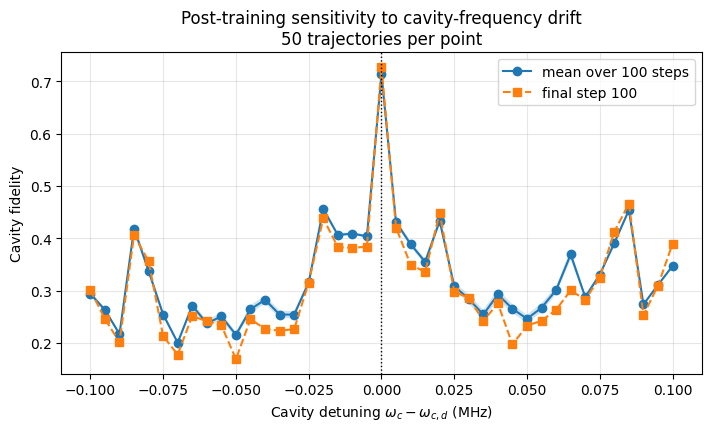

In [32]:
cav_det_mean_fid = np.zeros(len(sens_detuning_mhz))
cav_det_final_fid = np.zeros(len(sens_detuning_mhz))
cav_det_sem_fid = np.zeros(len(sens_detuning_mhz))

for i, delta_c in enumerate(sens_detuning_radus):
    key, subkey = jax.random.split(key)

    idle_cav_matrix_this = make_cavity_idle_matrix_detuned(
        N_cav,
        t1_cav,
        t_idle,
        jnp.asarray(delta_c, dtype=jnp.float32),
    )

    fids = np.asarray(
        sens_det_run_batch(
            subkey,
            flax_state,
            jnp.asarray(0.0, dtype=jnp.float32),
            jnp.asarray(delta_c, dtype=jnp.float32),
            idle_cav_matrix_this,
        )
    )

    fid_per_traj = np.mean(fids, axis=1)

    cav_det_mean_fid[i] = np.mean(fid_per_traj)
    cav_det_final_fid[i] = np.mean(fids[:, -1])
    cav_det_sem_fid[i] = np.std(fid_per_traj) / np.sqrt(sens_det_ntraj)

    print(
        f"cavity detuning {sens_detuning_mhz[i]:+.4f} MHz : "
        f"mean fid = {cav_det_mean_fid[i]:.6f}, "
        f"final fid = {cav_det_final_fid[i]:.6f}"
    )


fig, ax = plt.subplots(figsize=(7.0, 4.2), constrained_layout=True)

ax.plot(
    sens_detuning_mhz,
    cav_det_mean_fid,
    "o-",
    label=f"mean over {sens_det_num_steps} steps",
)
ax.fill_between(
    sens_detuning_mhz,
    cav_det_mean_fid - cav_det_sem_fid,
    cav_det_mean_fid + cav_det_sem_fid,
    alpha=0.2,
)
ax.plot(
    sens_detuning_mhz,
    cav_det_final_fid,
    "s--",
    label=f"final step {sens_det_num_steps}",
)

ax.axvline(0.0, color="k", linestyle=":", linewidth=1)
ax.set_xlabel(r"Cavity detuning $\omega_c - \omega_{c,d}$ (MHz)")
ax.set_ylabel("Cavity fidelity")
ax.set_title(
    f"Post-training sensitivity to cavity-frequency drift\n"
    f"{sens_det_ntraj} trajectories per point"
)
ax.grid(True, alpha=0.3)
ax.legend()

plt.savefig(run_folder / "sensitivity_cavity_frequency_detuning.png", dpi=200)
plt.savefig(run_folder / "sensitivity_cavity_frequency_detuning.pdf")

np.savez(
    run_folder / "sensitivity_cavity_frequency_detuning.npz",
    sens_detuning_mhz=sens_detuning_mhz,
    sens_detuning_radus=sens_detuning_radus,
    cav_det_mean_fid=cav_det_mean_fid,
    cav_det_final_fid=cav_det_final_fid,
    cav_det_sem_fid=cav_det_sem_fid,
    sens_det_ntraj=sens_det_ntraj,
    sens_det_num_steps=sens_det_num_steps,
)

plt.show()

# Normal GRAPE optimization with same Hamiltonian and target state

In [34]:
from tqdm.auto import tqdm
from datetime import datetime
import os
from pathlib import Path
jax.config.update("jax_enable_x64", True)

# Normal GRAPE: prepare |g,0> -> |g> tensor psi_target_cav
# Uses the already-defined feedback-GRAPE Hamiltonian through build_drive_htree.

psi_init_grape = tensor(basis(2), basis(N_cav, 0))       # |g,0>
psi_target_grape = tensor(basis(2), psi_target_cav)      # |g> ⊗ target cavity state

grape_optimizer = optax.adam(learning_rate=4e-3)


def grape_fidelity(psi, psi_target):
    overlap = hconj(psi_target) @ psi
    return jnp.abs(overlap[0, 0]) ** 2


def apply_grape_ctrl(grape_ctrl_coeffs):
    e_qub, e_cav = ctrl_from_coeffs(grape_ctrl_coeffs, bsplns_mids)

    # Uses the exact same drift + control Hamiltonians as feedback-GRAPE.
    htree = build_drive_htree(N_cav, chi, e_qub, e_cav)

    psi_t = sesolve_htree(htree, psi_init_grape, t_drive_intvs)
    return psi_t


@jax.jit
def grape_train_step(grape_ctrl_coeffs, grape_opt_state):
    def loss_fn(c):
        psi_t = apply_grape_ctrl(c)
        fid = grape_fidelity(psi_t[-1], psi_target_grape)
        return 1.0 - fid, fid

    (loss_val, fid_val), grads = jax.value_and_grad(loss_fn, has_aux=True)(grape_ctrl_coeffs)
    updates, grape_opt_state = grape_optimizer.update(grads, grape_opt_state)
    grape_ctrl_coeffs = optax.apply_updates(grape_ctrl_coeffs, updates)

    return grape_ctrl_coeffs, grape_opt_state, loss_val, fid_val

/home/user/dgx-suite/applications/server/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 5000/5000 [00:48<00:00, 103.30it/s, fid=0.999589]


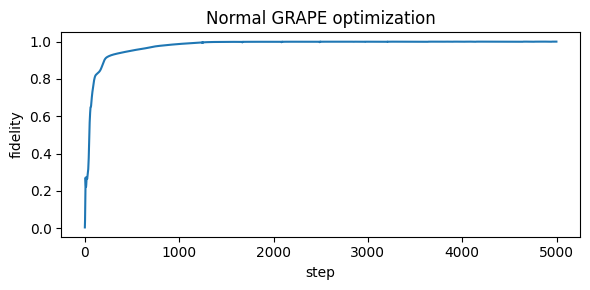

Final normal-GRAPE fidelity: 0.9995894645970688
grape_ctrl_coeffs shape: (4, 20)


In [35]:
key, subkey = jax.random.split(key)

# Same coefficient shape as the RNN output: [qubit I, qubit Q, cavity I, cavity Q]
grape_ctrl_coeffs = 0.04 * jax.random.normal(subkey, (4, num_bspln))

grape_opt_state = grape_optimizer.init(grape_ctrl_coeffs)

grape_fid_hist = []

n_steps = 5000

pbar = tqdm(range(n_steps))
for i in pbar:
    grape_ctrl_coeffs, grape_opt_state, grape_loss_val, grape_fid_val = grape_train_step(
        grape_ctrl_coeffs, grape_opt_state
    )
    grape_fid_hist.append(float(grape_fid_val))
    pbar.set_postfix(fid=f"{float(grape_fid_val):.6f}")

plt.figure(figsize=(6, 3))
plt.plot(grape_fid_hist)
plt.xlabel("step")
plt.ylabel("fidelity")
plt.title("Normal GRAPE optimization")
plt.tight_layout()
plt.show()

grape_ctrl_coeffs_np = np.asarray(grape_ctrl_coeffs, dtype=float)

print("Final normal-GRAPE fidelity:", grape_fid_hist[-1])
print("grape_ctrl_coeffs shape:", grape_ctrl_coeffs_np.shape)

In [36]:
pbar = tqdm(range(6000))
for i in pbar:
    grape_ctrl_coeffs, grape_opt_state, grape_loss_val, grape_fid_val = grape_train_step(
        grape_ctrl_coeffs, grape_opt_state
    )
    grape_fid_hist.append(float(grape_fid_val))
    pbar.set_postfix(fid=f"{float(grape_fid_val):.6f}")

100%|██████████| 6000/6000 [00:55<00:00, 108.19it/s, fid=0.999910]


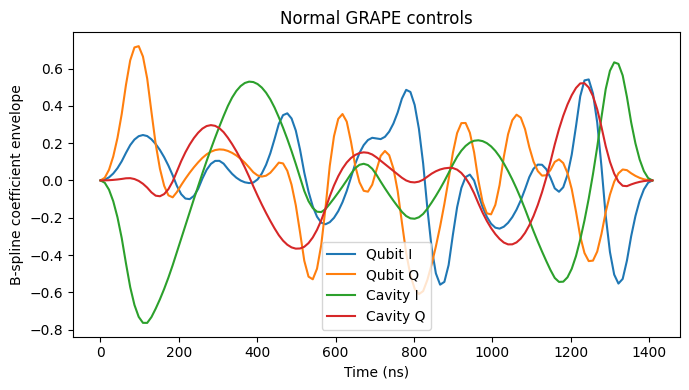

Max raw qubit envelope: 0.7200333148379938
Max raw cavity envelope: 0.7639248074894889
Max physical qubit envelope after mu_qub: 14.400666296759876
Max physical cavity envelope after mu_cav: 15.278496149789778


In [37]:
grape_fields_edges = grape_ctrl_coeffs_np @ np.asarray(bsplns_edges, dtype=float)

plt.figure(figsize=(7, 4))
plt.plot(np.asarray(t_drive_edges) * 1e3, grape_fields_edges[0], label="Qubit I")
plt.plot(np.asarray(t_drive_edges) * 1e3, grape_fields_edges[1], label="Qubit Q")
plt.plot(np.asarray(t_drive_edges) * 1e3, grape_fields_edges[2], label="Cavity I")
plt.plot(np.asarray(t_drive_edges) * 1e3, grape_fields_edges[3], label="Cavity Q")
plt.xlabel("Time (ns)")
plt.ylabel("B-spline coefficient envelope")
plt.title("Normal GRAPE controls")
plt.legend()
plt.tight_layout()
plt.show()

print("Max raw qubit envelope:", np.max(np.abs(grape_fields_edges[:2])))
print("Max raw cavity envelope:", np.max(np.abs(grape_fields_edges[2:])))
print("Max physical qubit envelope after mu_qub:", mu_qub * np.max(np.abs(grape_fields_edges[:2])))
print("Max physical cavity envelope after mu_cav:", mu_cav * np.max(np.abs(grape_fields_edges[2:])))

In [38]:
# Build OPX-compatible single B-spline basis sampled at 1 ns

t_ns = np.arange(0, T_ns_hw, 1)
t_us = t_ns / 1000.0

B_1ns = np.asarray(bspline_builder(t_us), dtype=float)
assert B_1ns.shape == (num_bspln, T_ns_hw)

eps = 1e-15
nz0 = np.where(np.abs(B_1ns[0]) > eps)[0]
s0_raw = int(nz0[0]) if len(nz0) else 0

s0_grid = int(np.round(s0_raw / delta_ns) * delta_ns)
s0_grid = (s0_grid // 4) * 4

assert 0 <= s0_grid
assert s0_grid + L_ns <= T_ns_hw

basis_single = B_1ns[0, s0_grid:s0_grid + L_ns].copy()
basis_single[0] = 0.0

max_err = 0.0
for i in range(num_bspln):
    si = s0_grid + i * delta_ns
    seg = B_1ns[i, si:si + L_ns]
    err = np.max(np.abs(seg - basis_single))
    max_err = max(max_err, err)

print("Max shift-match error:", max_err)
assert max_err < 1e-5

# Reconstruct full 1 ns envelopes too
grape_fields_1ns = grape_ctrl_coeffs_np @ B_1ns

# Save next to the feedback-GRAPE RNN weights / weights.bin
# This matches the directory used by save_cpp_weights(save_name, flax_state)
rnn_weights_dir = Path(os.path.abspath(save_name))

if not rnn_weights_dir.exists():
    raise FileNotFoundError(
        f"RNN weights directory does not exist yet: {rnn_weights_dir}\n"
        "Run the feedback-GRAPE save cell first, or check save_name."
    )

out_dir = rnn_weights_dir / "grape_bspline_coeffs"
out_dir.mkdir(parents=True, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H_%M")
fid_digits = int(np.floor(float(grape_fid_hist[-1]) * 10_000))
fid_str = f"{fid_digits:04d}"

bundle_filename = (
    f"grape_quad_bspline"
    f"fid_{fid_str}_Tns_{int(T_ns_hw)}_{timestamp}.npz"
)

bundle_path = out_dir / bundle_filename

np.savez(
    bundle_path,
    coeffs=np.asarray(grape_ctrl_coeffs_np, dtype=float),
    coeffs_raw=np.asarray(grape_ctrl_coeffs_np, dtype=float),
    fields_1ns=np.asarray(grape_fields_1ns, dtype=float),
    basis_single=np.asarray(basis_single, dtype=float),
    delta_ns=int(delta_ns),
    L_ns=int(L_ns),
    T_ns=int(T_ns_hw),
    T_us=float(T_us_hw),
    n=int(n),
    k=int(k),
    skip_left=int(skip_left),
    skip_right=int(skip_right),
    num_bspln=int(num_bspln),
    mu_qub=float(mu_qub),
    mu_cav=float(mu_cav),
    chi=float(chi),
    final_fidelity=float(grape_fid_hist[-1]),
)

print("Saved normal-GRAPE B-spline bundle:", bundle_path)

coeffs_cpp_path = out_dir / "grape_init_coeffs_80_f32.bin"

np.asarray(grape_ctrl_coeffs_np.reshape(-1), dtype=np.float32).tofile(coeffs_cpp_path)

print("Saved C++ initial GRAPE coefficients:", coeffs_cpp_path)

Max shift-match error: 1.0295347363520335e-07
Saved normal-GRAPE B-spline bundle: /home/user/python_experiments/train_feedback_grape/fg_trained/fock2/grape_bspline_coeffs/grape_quad_bsplinefid_9999_Tns_1408_20260703_10_24.npz
Saved C++ initial GRAPE coefficients: /home/user/python_experiments/train_feedback_grape/fg_trained/fock2/grape_bspline_coeffs/grape_init_coeffs_80_f32.bin


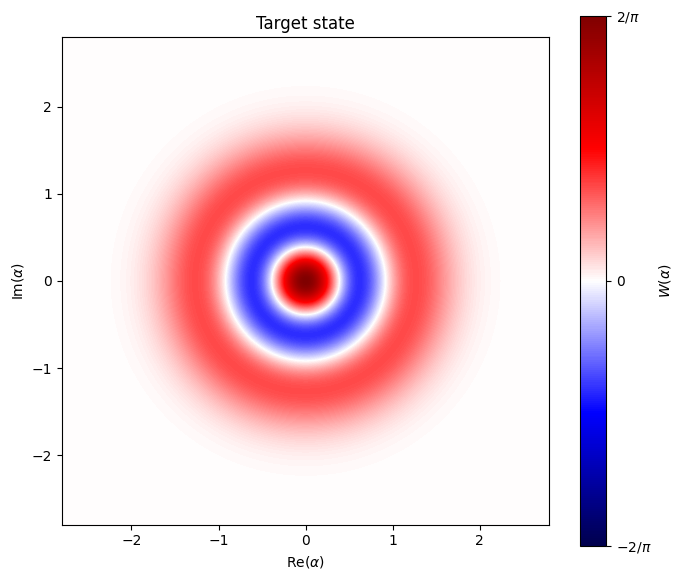

In [39]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

# Convert the normalized JAX state to a QuTiP ket
psi_qutip = qt.Qobj(
    np.asarray(psi_target_cav).reshape(-1),
    dims=[[N_cav], [1]],
)

# Coherent-state coordinates: alpha = (x + ip) / sqrt(2)
alpha = np.linspace(-2.8, 2.8, 301)
W = 2 * qt.wigner(
    psi_qutip,
    np.sqrt(2) * alpha,
    np.sqrt(2) * alpha,
)

# In this convention, every physical state satisfies |W(alpha)| <= 2/pi
W_limit = 2 / np.pi
levels = np.linspace(-W_limit, W_limit, 2000)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.contourf(
    alpha,
    alpha,
    W,
    levels=levels,
    cmap="seismic",
    vmin=-W_limit,
    vmax=W_limit,
    extend="neither",
)

ax.set_xlabel(r"$\mathrm{Re}(\alpha)$")
ax.set_ylabel(r"$\mathrm{Im}(\alpha)$")
ax.set_title(rf"Target state")
ax.set_aspect("equal")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r"$W(\alpha)$")
cbar.set_ticks([-2 / np.pi, 0, 2 / np.pi])
cbar.set_ticklabels([r"$-2/\pi$", "$0$", r"$2/\pi$"])

plt.tight_layout()
plt.show()